# Quantitative modelling of biological response dynamics reveals novel patterns in plant volatile signalling

**Authors**: Jamie M. Waterman, Gareth J. Moore, Loren K. Amdahl-Culleton, Sara
Hoefer, Matthias Erb

# Plotting and Fitting Functions

## Requirements

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import PolyCollection
import pandas as pd
from scipy.special import gamma
from scipy.optimize import differential_evolution, minimize, Bounds
import copy
import itertools
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

!python --version

Python 3.13.11


## Model and descriptors

In [3]:
def model_gamma(t, R_peak, t_peak, t_onset, t_mean, epsilon=0.1):
    """
    Compute a shifted gamma-like emission curve.
    
    Args:
        t (array): Time values.
        R_peak (float): Peak emission amplitude.
        t_peak (float): Time of peak emission.
        t_onset (float): Onset time of emission.
        t_mean (float): Mean-related shape control parameter.
        epsilon (float): Smoothing factor for onset ramp.
    
    Returns:
        array: Predicted emission values.
    """
    alpha = (t_mean - t_onset) / (t_mean - t_peak)
    beta = t_mean - t_peak
    t_adj = t - t_onset

    core = ((np.clip(t_adj, 1e-10, None) / (t_peak - t_onset)) ** (alpha - 1)) * \
           np.exp(-(t_adj - (t_peak - t_onset)) / beta)

    ramp = 1 / (1 + np.exp(-(t - t_onset) / epsilon))
    
    model_pred = R_peak * ramp * core

    model_pred = np.nan_to_num(model_pred, nan=0.0, posinf=0.0, neginf=0.0)
    return model_pred

In [4]:
def shape(t_onset, t_peak, t_mean):
    """
    Compute the shape ratio of the emission curve.
    
    Args:
        t_onset (float): Onset time.
        t_peak (float): Peak time.
        t_mean (float): Mean time.
    
    Returns:
        float: Shape ratio.
    """
    return (t_mean - t_peak) / (t_mean - t_onset)

def duration(t_onset, t_peak, t_mean):
    """
    Compute the duration between onset and mean time.
    
    Args:
        t_onset (float): Onset time.
        t_peak (float): Peak time.
        t_mean (float): Mean time.
    
    Returns:
        float: Duration value.
    """
    return t_mean - t_onset

def total_integral_model_gamma(R_peak, t_peak, t_onset, t_mean):
    """
    Compute the total integral of the gamma-based emission model.
    
    Args:
        R_peak (float): Peak emission amplitude.
        t_peak (float): Peak time.
        t_onset (float): Onset time.
        t_mean (float): Mean time.
    
    Returns:
        float: Total integrated emission.
    """
    alpha = (t_mean - t_onset) / (t_mean - t_peak)
    beta = t_mean - t_peak
    t0 = t_peak - t_onset
    A = R_peak * (t0 ** (1 - alpha)) * np.exp(t0 / beta)
    total = A * (beta ** alpha) * gamma(alpha)
    
    return total

## Loading and cleaning

In [5]:
def subtract_background(data, type = 'a'):
    """
    Subtract background channels from emission data using per-comp scaling.
    
    Args:
        data (DataFrame): Input dataframe containing emission measurements.
        type (str): Label identifying background rows to subtract.
    
    Returns:
        DataFrame: Data with background-subtracted emission values.
    """

    processed_frames = []
    raw_exists = 'Emission_RAW' in data.columns

    grouped_data = data.groupby('comp')

    time_cut = 0

    for comp, group_data in grouped_data:
        background_data = group_data[group_data['Type'] == type]

        if not background_data.empty:
            # Pivot background
            bg_emission = background_data.pivot(index='time', columns='Channel_number', values='Emission')
            bg_mean = np.mean(bg_emission, axis=1)

            if raw_exists:
                bg_raw = background_data.pivot(index='time', columns='Channel_number', values='Emission_RAW')
                bg_raw_mean = np.mean(bg_raw, axis=1)

            non_bg_data = group_data[group_data['Type'] != type].copy()
            non_bg_emission = non_bg_data.pivot(index='time', columns='Channel_number', values='Emission')
            if raw_exists:
                non_bg_raw = non_bg_data.pivot(index='time', columns='Channel_number', values='Emission_RAW')

            adjusted_em = pd.DataFrame(index=non_bg_emission.index, columns=non_bg_emission.columns)
            if raw_exists:
                adjusted_raw = pd.DataFrame(index=non_bg_raw.index, columns=non_bg_raw.columns)

            for ch in non_bg_emission.columns:
                e_curve = non_bg_emission[ch]
                bg_curve = bg_mean

                
                def residuals(scale, e, b):
                    idx = e.index[e.index <= time_cut]
                    return np.nansum((e.loc[idx] - b.loc[idx] * scale) ** 2)

                result = minimize(residuals, 1.0, args=(e_curve, bg_curve), method='Nelder-Mead')
                scale = result.x[0]
                

                adjusted_em[ch] = e_curve - bg_curve * scale

                if raw_exists:
                    raw_curve = non_bg_raw[ch]
                    adjusted_raw[ch] = raw_curve - bg_raw_mean * scale

            adj_df = adjusted_em.reset_index().melt(id_vars='time', var_name='Channel_number', value_name='Emission')
            meta = non_bg_data.drop(columns=['Emission'] + (['Emission_RAW'] if raw_exists else []))
            adj_df = adj_df.merge(meta, on=['time', 'Channel_number'], how='left')

            if raw_exists:
                raw_df = adjusted_raw.reset_index().melt(id_vars='time', var_name='Channel_number', value_name='Emission_RAW')
                adj_df = adj_df.merge(raw_df, on=['time', 'Channel_number'], how='left')

            adjusted_group = pd.concat([adj_df, background_data], ignore_index=True)
        else:
            adjusted_group = group_data

        processed_frames.append(adjusted_group)

    return pd.concat(processed_frames, ignore_index=True)

In [6]:
def reconstruct_with_svd(emission_data):
    """
    Reconstruct emission signals using the strongest SVD component.
    
    Args:
        emission_data (DataFrame): Long-format emission data with time and channel columns.
    
    Returns:
        DataFrame: Reconstructed emissions merged with original raw values.
    """
    # Reshape data: Time as rows, Channels as columns
    emission_matrix = emission_data.pivot(index='time', columns='Channel_number', values='Emission')
    
    # Standardize the data
    scaler = StandardScaler()
    standardized_matrix = scaler.fit_transform(emission_matrix.fillna(0))
    
    # Perform SVD decomposition
    U, S, Vt = np.linalg.svd(standardized_matrix, full_matrices=False)
    
    # Reconstruct with the strongest singular component
    strongest_component = np.outer(U[:, 0], S[0] * Vt[0, :])
    reconstructed_matrix = scaler.inverse_transform(strongest_component)
    
    # Convert back to long-format DataFrame
    reconstructed_df = pd.DataFrame(reconstructed_matrix, index=emission_matrix.index, columns=emission_matrix.columns)
    reconstructed_long = reconstructed_df.reset_index().melt(id_vars='time', var_name='Channel_number', value_name='Emission')
    
    # Merge with original data to get Emission_RAW
    merged = emission_data.copy()
    merged = merged.rename(columns={'Emission': 'Emission_RAW'})
    reconstructed_long = reconstructed_long.merge(merged, on=['time', 'Channel_number'])
    
    return reconstructed_long

In [7]:
def clean_and_reconstruct(data, background=True, norm=None):
    """
    Clean emission data, reconstruct signals with SVD, and optionally subtract background.
    
    Args:
        data (DataFrame): Input emission dataset.
        background (bool): Whether to subtract background after reconstruction.
        norm (str or None): Column name used to normalize emissions.
    
    Returns:
        DataFrame: Cleaned and reconstructed emission data.
    """

    processed_frames = []

    if norm:
        data['Emission'] = data['Emission'] / data[norm]

    grouped_data = data.groupby(['Type', 'comp'])

    for (type_group, comp_group), group_data in grouped_data:
        reconstructed_emissions = reconstruct_with_svd(group_data[['time', 'Channel_number', 'Emission']])

        reconstructed_group = group_data.drop(columns='Emission').merge(
            reconstructed_emissions, on=['time', 'Channel_number'], how='left'
        )

        processed_frames.append(reconstructed_group)

    cleaned_data = pd.concat(processed_frames, ignore_index=True)

    if 'Unnamed: 0' in cleaned_data.columns:
        cleaned_data = cleaned_data.drop(columns=['Unnamed: 0'])

    if background:
        final_data = subtract_background(cleaned_data)
    else:
        final_data = cleaned_data

    return final_data


## Fitting Functions

In [135]:
# Parameter Configs
"""
We set universal parameter configurations for each volatile
"""
param_config_DMNT = {
    #'R_peak': {'value': 20, 'min': 5, 'max':  60 },
    #'t_peak': {'value': 2.8, 'min': 1.5, 'max':  3.5 },
    't_onset': {'value': 1.9, 'min': 0, 'max':  10 },
    't_mean': {'value': 6, 'min': 0, 'max': 20 }
}

param_config_indole = {
    #'R_peak': {'value': 50, 'min': 30, 'max':  90 },
    #'t_peak': {'value': 3.8, 'min': 2, 'max':  4 },
    't_onset': {'value': 1.4, 'min': 0, 'max':  10 },
    't_mean': {'value': 6, 'min': 1, 'max': 20 }
}

param_config_TMTT = {
    #'R_peak': {'value': 40, 'min': 2, 'max':  10 },
    #'t_peak': {'value': 7, 'min': 6, 'max':  10 },
    't_onset': {'value': 1.4, 'min': 0, 'max': 10  },
    't_mean': {'value': 10, 'min': 1, 'max': 20 }
}

param_config_sesq = {
    #'R_peak': {'value': 40, 'min': 10, 'max':  50 },
    #'t_peak': {'value': 7, 'min': 6, 'max':  9 },
    't_onset': {'value': 1.4, 'min': 0, 'max':  10 },
    't_mean': {'value': 10, 'min': 1, 'max': 20 }
}

param_config_mono = {
    #'R_peak': {'value': 40, 'min': 25, 'max':  150 },
    #'t_peak': {'value': 6, 'min': 3.1, 'max':  8 },
    't_onset': {'value': 0.5, 'min': 0, 'max': 10 },
    't_mean': {'value': 6.1, 'min': 1, 'max': 20 }
}


In [8]:
def run_de_then_slsqp(objective, x0, bounds, constraints):
    """
    Run differential evolution followed by SLSQP for robust optimization.
    
    Args:
        objective (callable): Objective function to minimize.
        x0 (array): Initial guess for parameters.
        bounds (iterable): Parameter bounds.
        constraints (iterable): Constraints for the SLSQP stage.
    
    Returns:
        tuple: Optimized parameters and success flag.
    """

    try:
        # --- Stage 1: Global optimization ---
        de_result = differential_evolution(
            objective,
            bounds=bounds,
            strategy='best1bin',
            maxiter=50000,
            polish=False
        )
    
        # --- Stage 2: Local refinement ---
        local_result = minimize(
            objective,
            de_result.x,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 50000}
        )
    
        return local_result.x if local_result.success else de_result.x, True
        
    except Exception as e:
        print(f"Optimization error: {e}")
        return None, False

def r_squared(emission, fit):
    """
    Compute the coefficient of determination between data and fit.
    
    Args:
        emission (array): Observed values.
        fit (array): Fitted values.
    
    Returns:
        float: R squared value.
    """

    ss_tot = np.sum((emission - emission.mean())**2)
    ss_res = np.sum((emission - fit)**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0
    return r2
    

In [9]:
def process_single_group(data, type_value, comp_value, param_config,
                         r_quared_limit=0.0, lambda_prior=1):
    """
    Fit a single gamma emission curve for one type–compound group.
    
    Args:
        data (DataFrame): Input dataset containing emission channels.
        type_value (str): Type label to filter.
        comp_value (str): Compound label to filter.
        param_config (dict): Parameter bounds and initial values.
        r_quared_limit (float): Minimum R² threshold for accepting fits.
        lambda_prior (float): Weight of the prior-curve penalty.
    
    Returns:
        list: Fitting results and metadata for accepted channels.
    """

    # Filter data for the specified type and comp.
    data_group = data[(data['Type'] == type_value) & (data['comp'] == comp_value)]
    results = []

    def fit_emission_curve(time, emission, prior, param_config):
        param_config = copy.deepcopy(param_config)
        t_peak_data = time[np.argmax(emission)]
        em_max = emission.max()
        mask = time >= 0

        if ('t_peak' not in param_config or
            param_config['t_peak'].get('value') is None or
            np.isnan(param_config['t_peak'].get('value', np.nan))):
            param_config['t_peak'] = {
                'value': t_peak_data,
                'min': 0.8 * t_peak_data,
                'max': 1.2 * t_peak_data
            }

        if ('R_peak' not in param_config or
            param_config['R_peak'].get('value') is None or
            np.isnan(param_config['R_peak'].get('value', np.nan))):
            param_config['R_peak'] = {
                'value': em_max,
                'min': 0.8 * em_max,
                'max': 1.2 * em_max
            }

        param_names = ['R_peak', 't_peak', 't_onset', 't_mean']
        x0 = [param_config[n]['value'] for n in param_names]
        bounds_list = [(param_config[n]['min'], param_config[n]['max']) for n in param_names]

        def objective(x):
            params = dict(zip(param_names, x))
            model_pred = model_gamma(time[mask], **params)
            loss_prior = np.sum((model_pred - prior[mask]) ** 2)
            return np.sum((model_pred - emission[mask]) ** 2) + lambda_prior * loss_prior

        constraints = [
            {'type': 'ineq', 'fun': lambda x: (x[3] - x[1]) - 0.1 * (x[3] - x[2])},
            {'type': 'ineq', 'fun': lambda x: x[1] - x[2] - 0.1},
            {'type': 'ineq', 'fun': lambda x: x[3] - x[1] - 0.1},
        ] 

        result_x, success = run_de_then_slsqp(objective, x0, bounds_list, constraints)
        if not success:
            return None
        
        # --- Postprocessing ---
        fitted_params = dict(zip(param_names, result_x))
        fitted_emission = model_gamma(time, **fitted_params)

        integral = total_integral_model_gamma(**fitted_params)
        shape_val = shape(fitted_params['t_onset'], fitted_params['t_peak'], fitted_params['t_mean'])
        duration_val = duration(fitted_params['t_onset'], fitted_params['t_peak'], fitted_params['t_mean'])

        return {
            **{f"{k}_fit": v for k, v in fitted_params.items()},
            'duration': duration_val,
            'shape': shape_val,
            'fitted_emission': fitted_emission,
            'prior': prior,
            'time': time,
            'emission': emission,
            'integral': integral
        }

    # --- Loop over channels ---
    for channel in data_group['Channel_number'].unique():
        data_channel = data_group[data_group['Channel_number'] == channel]
        time = data_channel['time'].values
        emission = data_channel['Emission_RAW'].values
        prior = data_channel['Emission'].values

        try:
            fit_results = fit_emission_curve(time, emission, prior, param_config)
        except Exception as e:
            print(f"Fitting failed for channel {channel}: {e}")
            continue

        # R²
        r_2 = r_squared(emission, fit_results['fitted_emission'])
        print(f'Channel {channel}, Type {type_value}, R² = {r_2:.3f}')
        if r_2 < r_quared_limit:
            print(f"Channel {channel} not accepted (R² below threshold).")
            continue
            
        if np.isnan(fit_results['integral']):
            print('Curve fit failed (NaN integral).')
            continue

        fit_results['Type'] = type_value
        fit_results['comp'] = comp_value
        fit_results['Channel_number'] = channel
        fit_results['intensity1'] = data_channel['intensity1'].iloc[0]
        fit_results['Totalbio'] = data_channel['Totalbio'].iloc[0]
        fit_results['Leaf3'] = data_channel['Leaf3'].iloc[0]
        fit_results['d1_time'] = data_channel['d1_time'].iloc[0]

        results.append(fit_results)

    return results


## Functions for plotting and saving results¶

In [10]:
def plot_individual_fits(res, prior = False):
    """
    Plot fitted emission curves alongside raw data and optional priors.
    
    Args:
        res (list): Nested list of fit-result dictionaries.
        prior (bool): Whether to plot the prior curve.
    
    Returns:
        None: Displays plots.
    """

    for r in res:
        for result in r:
            t = result['time']
            emission = result['emission']
            em_f = result['fitted_emission']
            em_p = result['prior']
            type = result['Type']
            if type != 'r':
                plt.plot(t, emission, label = 'em')
                plt.plot(t , em_f, label = type)
                if prior:
                    plt.plot(t , em_p, label = 'prior')
                plt.legend()
                plt.minorticks_on()
                plt.grid(True, which = 'both')
                plt.show()

In [11]:
def plot_individual_fits_trip(res, prior = False, sep = False):
    """
    Plot triple-curve fits with optional prior and component separation.
    
    Args:
        res (list): Nested list of fit-result dictionaries.
        prior (bool): Whether to plot the prior curve.
        sep (bool): Whether to plot individual component curves.
    
    Returns:
        None: Displays plots.
    """

    for r in res:
        for result in r:
            t = result['time']
            emission = result['emission']
            em_f = result['fitted_emission']
            em_f1 = result['fitted_emission1']
            em_f2 = result['fitted_emission2']
            em_f3 = result['fitted_emission3']
            em_p = result['prior']
            type = result['Type']
            if type != 'r':
                plt.plot(t, emission, label = 'em')
                plt.plot(t , em_f, label = type)
                if prior:
                    plt.plot(t , em_p, label = 'prior')
                if sep:
                    plt.plot(t, em_f1, label = "1")
                    plt.plot(t, em_f2, label = "2")
                    plt.plot(t, em_f3, label = "3")
                plt.legend()
                plt.minorticks_on()
                plt.grid(True, which = 'both')
                plt.show()

In [12]:
def plot_fit_results_gamma(results, features='intensity1'):
    """
    Plot aggregated gamma-fit metrics against selected features.
    
    Args:
        results (list): Nested list of fit-result dictionaries.
        features (str or list): Feature name(s) to plot on the x-axis.
    
    Returns:
        None: Displays plots.
    """

    # Flatten results into DataFrame
    flat = [item for sub in results for item in sub]
    df = pd.DataFrame(flat)

    # Ensure features is a list
    if isinstance(features, str):
        features = [features]

    # Plotting
    types = df['Type'].dropna().unique()
    colors = plt.cm.tab10.colors
    cmap = {t: colors[i % 10] for i, t in enumerate(types)}

    for feat in features:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        plt.subplots_adjust(hspace=0.4, wspace=0.3)

        def panel(ax, yroot, ylabel, subtitle):
            col1 = f"{yroot}"
            if yroot == "R_peak":
                col1 = f"{yroot}_fit"

            for t in types:
                sub = df[df['Type'] == t]
                color = cmap[t]

                if col1 in sub.columns:
                    g = sub[[feat, col1]].dropna().groupby(feat)[col1]
                    x = g.mean().index
                    y = g.mean().values
                    err = g.std().values / np.sqrt(g.count().values)
                    ax.errorbar(
                        x, y, yerr=err,
                        fmt='o-', color=color,
                        capsize=4, markersize=8, alpha=0.9,
                        label=t
                    )

            ax.set_xlabel(feat, fontsize=14)
            ax.set_ylabel(ylabel, fontsize=14)
            ax.set_title(subtitle, fontsize=16)
            #ax.legend()

        # Plot in desired layout
        panel(axes[0, 0], 'integral',  'Integral',  f"Total Emission vs {feat}")
        panel(axes[1, 0], 'R_peak',    'R_peak',    f"R_peak vs {feat}")
        panel(axes[0, 1], 'duration',  'Duration',  f"Duration vs {feat}")
        panel(axes[1, 1], 'shape',     'Shape',     f"Shape vs {feat}")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

In [13]:
def plot_fit_params_gamma(results, features='intensity1'):
    """
    Plot fitted gamma parameters against selected features.
    
    Args:
        results (list): Nested list of fit-result dictionaries.
        features (str or list): Feature name(s) to plot on the x-axis.
    
    Returns:
        None: Displays plots.
    """

    # Flatten results into DataFrame
    flat = [item for sub in results for item in sub]
    df = pd.DataFrame(flat)

    # Ensure features is a list
    if isinstance(features, str):
        features = [features]

    # Plotting
    types = df['Type'].dropna().unique()
    colors = plt.cm.tab10.colors
    cmap = {t: colors[i % 10] for i, t in enumerate(types)}

    for feat in features:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        plt.subplots_adjust(hspace=0.4, wspace=0.3)

        def panel(ax, yroot, ylabel, subtitle):
            col1 = f"{yroot}_fit"

            for t in types:
                sub = df[df['Type'] == t]
                color = cmap[t]

                if col1 in sub.columns:
                    data = sub[[feat, col1]].dropna()
    
                    # Raw data points
                    ax.scatter(
                        data[feat], data[col1],
                        color=color, alpha=0.2, s=30, label=None
                    )
                    
                    g = sub[[feat, col1]].dropna().groupby(feat)[col1]
                    x = g.mean().index
                    y = g.mean().values
                    err = g.std().values / np.sqrt(g.count().values)
                    ax.errorbar(
                        x, y, yerr=err,
                        fmt='o-', color=color,
                        capsize=4, markersize=8, alpha=0.9,
                        label=t
                    )

            ax.set_xlabel(feat, fontsize=14)
            ax.set_ylabel(ylabel, fontsize=14)
            ax.set_title(subtitle, fontsize=16)
            ax.yaxis.get_offset_text().set_visible(False)
            #ax.legend()

        # Plot in desired layout
        panel(axes[0, 0], 't_onset',   't_onset',  f"t_onset vs {feat}")
        panel(axes[1, 0], 't_peak',    't_peak',   f"t_peak vs {feat}")
        panel(axes[0, 1], 't_mean',    't_mean',   f"t_mean vs {feat}")
        panel(axes[1, 1], 'R_peak',    'R_peak',   f"R_peak vs {feat}")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.ticklabel_format(style='plain', axis='y', useOffset=False)
        plt.show()

In [14]:
def plot_3d_mean_fitting_results_by_type(fit_results, title=''):
    """
    Plot 3D mean emission curves and fitted curves grouped by type.
    
    Args:
        fit_results (list): Nested list of fit-result dictionaries.
        title (str): Plot title.
    
    Returns:
        None: Displays a 3D plot.
    """

    # Flatten the double list if necessary
    if isinstance(fit_results, list) and isinstance(fit_results[0], list):
        fit_results = [item for sublist in fit_results for item in sublist]

    types = sorted(set(res['Type'] for res in fit_results))

    color_cycle = itertools.cycle(plt.cm.tab10.colors)
    type_colors = {t: next(color_cycle) for t in types}

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection='3d')
    y_offset = np.arange(len(types))

    for y, t in zip(y_offset, types):
        type_results = [res for res in fit_results if res['Type'] == t]

        # Make a union of all time points
        all_times = np.unique(np.concatenate([res['time'] for res in type_results]))
        all_times.sort()

        # Interpolate all emissions to this grid
        emissions = [np.interp(all_times, res['time'], res['emission']) for res in type_results]
        fitted = [np.interp(all_times, res['time'], res['fitted_emission']) for res in type_results]

        emissions = np.array(emissions)
        fitted = np.array(fitted)

        emission_mean = np.mean(emissions, axis=0)
        emission_std = np.std(emissions, axis=0)
        fitted_mean = np.mean(fitted, axis=0)

        # Plot observed emission with error
        ax.plot(all_times, emission_mean, zs=y, zdir='y', color=type_colors[t], label=f"Type {t}", alpha=0.7)
        ax.plot(all_times, fitted_mean, zs=y, zdir='y', 
                color='black', linestyle='--', alpha=0.9)
        

        verts = [list(zip(all_times, emission_mean - emission_std)) +
                 list(zip(all_times[::-1], (emission_mean + emission_std)[::-1]))]
        poly = PolyCollection(verts, facecolors=[type_colors[t]], alpha=0.2)
        ax.add_collection3d(poly, zs=y, zdir='y')


    ax.set_xlabel("Time")
    ax.set_ylabel("Type")
    ax.set_zlabel("Emission")
    ax.set_yticks(y_offset)
    ax.set_yticklabels(types)
    ax.view_init(elev=30, azim=-60)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [15]:
def plot_emission_data(data, plot_type='mean_error', comps = ['indole', 'DMNT', 'mono'], types=None, legend = True):
    """
    Plot emission data by compound with options for means, error bands, or all curves.
    
    Args:
        data (DataFrame): Emission dataset.
        plot_type (str): Plot mode ('mean_error', 'all_curves', 'combined').
        comps (list): Compounds to include.
        types (list or None): Type labels to plot.
        legend (bool): Whether to display the legend.
    
    Returns:
        None: Displays plots.
    """

    for comp in comps:
        plt.figure(figsize=(12, 6))
        plt.title(f'{comp}')
        plt.xlabel('Time')
        plt.ylabel('Emission')

        # Filter types if a list is provided
        available_types = sorted(data['Type'].unique())
        selected_types = types if types else available_types

        for type_ in selected_types:
            if type_ not in available_types:
                continue  # Skip types not in the dataset

            filtered_data = data[(data['Type'] == type_) & (data['comp'] == comp)]
            
            if plot_type in ['mean_error', 'combined']:
                # Calculate mean and standard deviation
                mean_emission = filtered_data.groupby('time')['Emission'].mean()
                std_emission = filtered_data.groupby('time')['Emission'].std()

                # Plot mean with error bands
                plt.plot(mean_emission.index, mean_emission, label=f'{type_} (mean)')
                plt.fill_between(
                    mean_emission.index,
                    mean_emission - std_emission,
                    mean_emission + std_emission,
                    alpha=0.3
                )
            
            if plot_type in ['all_curves', 'combined']:
                # Plot all individual curves
                for channel in filtered_data['Channel_number'].unique():
                    channel_data = filtered_data[filtered_data['Channel_number'] == channel]
                    plt.plot(
                        channel_data['time'], 
                        channel_data['Emission'], 
                        alpha=0.5, 
                        linestyle='--',
                        label=f'{type_} (Channel {channel})' if plot_type == 'all_curves' else None
                    )
        plt.minorticks_on()
        plt.grid(True, which = 'both')
        if legend:
            plt.legend()
        plt.show()

In [16]:
def save_results_to_csv(results, name, array_cols=None):
    """
    Save flattened fit results to CSV, exploding array columns into rows.
    
    Args:
        results (list): Nested list of fit-result dictionaries.
        name (str): Output filename (without extension).
        array_cols (list or None): Columns containing arrays to expand.
    
    Returns:
        None: Writes a CSV file.
    """

    path = "Submitted_results/" + str(name) + ".csv"
    
    if array_cols is None:
        array_cols = [
            'time', 'emission', 'prior', 'fitted_emission'
        ]
    flat = [d for group in results for d in group]
    df = pd.DataFrame(flat)
    for col in array_cols:
        if col in df.columns:
            df[col] = df[col].apply(lambda arr: arr.tolist())
    df = df.explode(array_cols, ignore_index=True)
    df.to_csv(path, index=False, encoding='utf-8-sig')
    print(f"Saved {len(df)} rows to {path}")

# Figure 1: Theoretical examination 

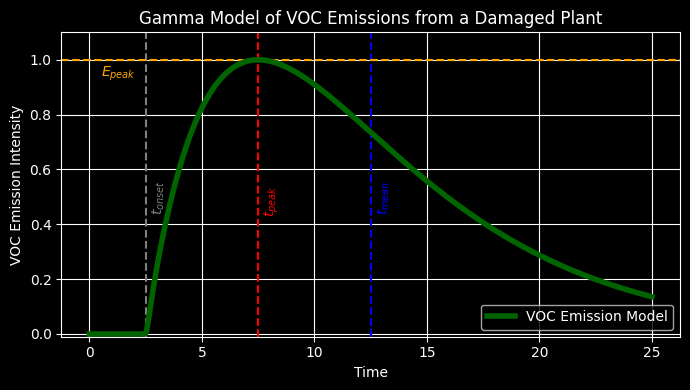

In [17]:
# Figure 1A
time = np.linspace(0, 25, 500)
R_peak, t_peak, t_onset, t_mean = 1, 7.5, 2.5, 12.5
t_rise = t_peak - t_onset
t_decay = t_mean - t_peak

# Generate curve
emission = model_gamma(time, R_peak, t_peak, t_onset, t_mean)

plt.figure(figsize=(7, 4))
plt.axvline(t_onset, linestyle='--', color='gray')
plt.axvline(t_peak, linestyle='--', color='red')
plt.axvline(t_mean, linestyle='--', color='blue')
plt.axhline(R_peak, linestyle = '--', color = 'orange')
plt.text(t_onset + 0.2, R_peak * 0.45, r'$t_{onset}$', rotation=90, color='gray')
plt.text(t_peak + 0.2, R_peak * 0.45, r'$t_{peak}$', rotation=90, color='red')
plt.text(t_mean + 0.2, R_peak * 0.45, r'$t_{mean}$', rotation=90, color='blue')
plt.text(0.5, R_peak*0.94, r'$E_{peak}$', rotation=0, color='orange')
plt.xlabel("Time")
plt.ylabel("VOC Emission Intensity")
plt.title("Gamma Model of VOC Emissions from a Damaged Plant")
plt.plot(time, emission, label='VOC Emission Model', color='darkgreen', linewidth=4)
plt.tight_layout()
plt.legend()
plt.grid(True, which = 'both')
plt.ylim(-0.01, 1.1)
plt.show()

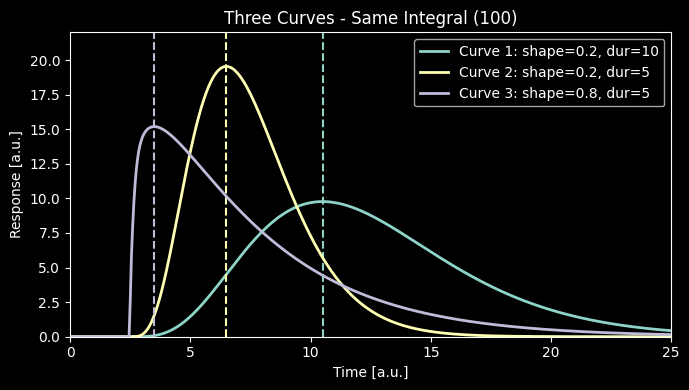

In [18]:
time = np.linspace(0, 25, 500)
# Target integral
target_integral = 100
R_peak_ref = 2  # initial guess, will be rescaled
t_onset = 2.5

shape1, shape2 = 0.2, 0.8
dur1, dur2 = 10, 5
# Define curves (shape, duration)
curves = [
    (shape1, dur1),  # Curve 1
    (shape1, dur2),  # Curve 2
    (shape2, dur2)   # Curve 3
]

plt.figure(figsize=(7, 4))

for i, (shape_val, duration_val) in enumerate(curves, start=1):
    t_mean = t_onset + duration_val
    t_peak = t_onset + duration_val * (1 - shape_val)
    
    # Compute current integral for reference R_peak
    integral_ref = total_integral_model_gamma(R_peak_ref, t_peak, t_onset, t_mean)
    
    # Scale R_peak to achieve target integral
    R_peak_adj = R_peak_ref * target_integral / integral_ref
    
    # Generate emission curve
    emission = model_gamma(time, R_peak_adj, t_peak, t_onset, t_mean)
    
    plt.plot(time, emission, linewidth=2, label=f"Curve {i}: shape={shape_val}, dur={duration_val}")
    plt.axvline(t_peak, linestyle='--', color=plt.gca().lines[-1].get_color())

plt.xlabel("Time [a.u.]")
plt.ylabel("Response [a.u.]")
plt.title("Three Curves - Same Integral (100)")
plt.legend()
plt.ylim(0,22)
plt.xlim(0,25)
plt.tight_layout()
plt.show()


# Figure 2: Single Damage Experiments

## Dose Dependence

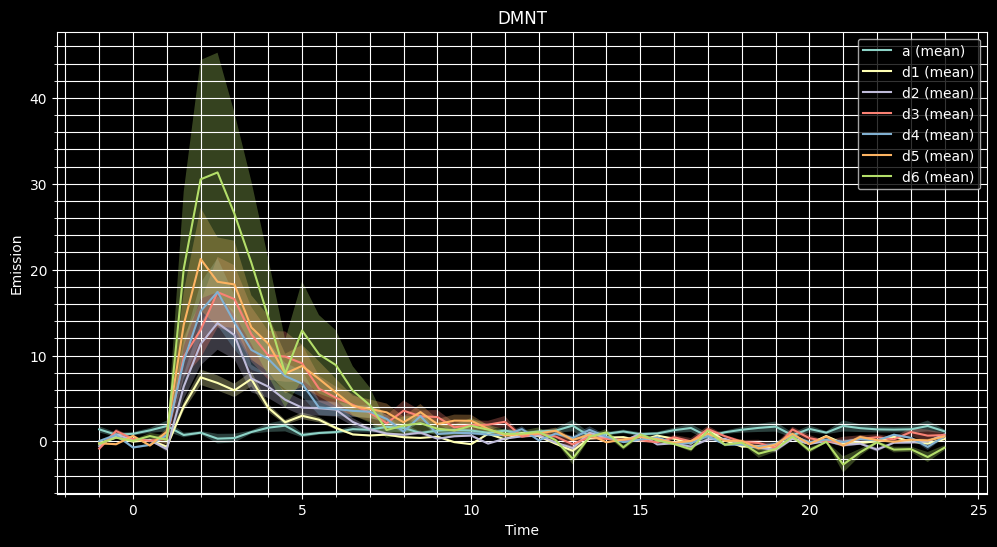

In [116]:
file_path = 'singledose_sub.csv'
dirty_data = pd.read_csv(file_path)
data_dose = clean_and_reconstruct(dirty_data, norm = 'Leaf3')
plot_emission_data(data_dose, plot_type='mean_error', comps = ['DMNT'])

d1
Channel 23, Type d1, R² = 0.705
Channel 30, Type d1, R² = 0.665
Channel 50, Type d1, R² = 0.776
Channel 67, Type d1, R² = 0.729
Channel 79, Type d1, R² = 0.878
d2
Channel 7, Type d2, R² = 0.857
Channel 17, Type d2, R² = 0.864
Channel 25, Type d2, R² = 0.859
Channel 74, Type d2, R² = 0.916
Channel 77, Type d2, R² = 0.915
d3
Channel 6, Type d3, R² = 0.854
Channel 19, Type d3, R² = 0.635
Channel 66, Type d3, R² = 0.955
Channel 71, Type d3, R² = 0.939
Channel 96, Type d3, R² = 0.924
d4
Channel 5, Type d4, R² = 0.833
Channel 11, Type d4, R² = 0.892
Channel 59, Type d4, R² = 0.882
Channel 72, Type d4, R² = 0.917
Channel 95, Type d4, R² = 0.959
d5
Channel 24, Type d5, R² = 0.900
Channel 29, Type d5, R² = 0.974
Channel 49, Type d5, R² = 0.936
Channel 62, Type d5, R² = 0.934
Channel 78, Type d5, R² = 0.952
d6
Channel 12, Type d6, R² = 0.953
Channel 18, Type d6, R² = 0.906
Channel 26, Type d6, R² = 0.863
Channel 60, Type d6, R² = 0.946
Channel 80, Type d6, R² = 0.978


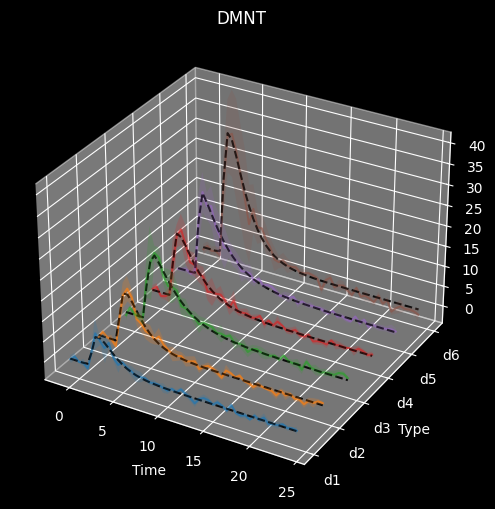

Saved 1530 rows to Submitted_results/Results_DMNT_dose.csv


In [117]:
param_config = copy.deepcopy(param_config_DMNT)

comp = 'DMNT'
res = Results_DMNT_dose = []
data = data_dose
for type in sorted(data.Type.unique()):
    if type not in ['a']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
        res.append(individual_results)

plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='intensity1')
#plot_fit_params_gamma(res, features='intensity1')

#plot_individual_fits(res,prior = True) #sep = True)
save_results_to_csv(res, 'Results_DMNT_dose')

## Time of Day

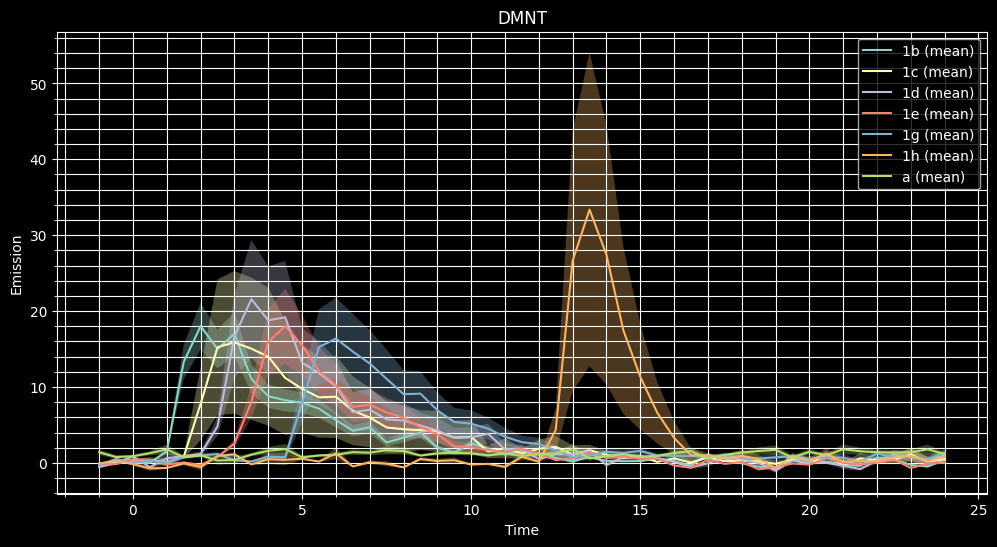

In [118]:
file_path = 'time_of_day_sub.csv'
dirty_data = pd.read_csv(file_path)
data_cir = clean_and_reconstruct(dirty_data, norm = 'Leaf3')
plot_emission_data(data_cir, plot_type='mean_error', comps = ['DMNT'])

1b
Channel 32, Type 1b, R² = 0.888
Channel 48, Type 1b, R² = 0.896
Channel 53, Type 1b, R² = 0.923
Channel 85, Type 1b, R² = 0.949
Channel 89, Type 1b, R² = 0.921
1c
Channel 31, Type 1c, R² = 0.921
Channel 47, Type 1c, R² = 0.961
Channel 55, Type 1c, R² = 0.946
Channel 73, Type 1c, R² = 0.797
Channel 102, Type 1c, R² = 0.892
1d
Channel 37, Type 1d, R² = 0.834
Channel 41, Type 1d, R² = 0.973
Channel 56, Type 1d, R² = 0.953
Channel 83, Type 1d, R² = 0.958
Channel 84, Type 1d, R² = 0.930
1e
Channel 38, Type 1e, R² = 0.946
Channel 43, Type 1e, R² = 0.936
Channel 54, Type 1e, R² = 0.904
Channel 86, Type 1e, R² = 0.970
Channel 97, Type 1e, R² = 0.926
1g
Channel 36, Type 1g, R² = 0.897
Channel 42, Type 1g, R² = 0.927
Channel 61, Type 1g, R² = 0.922
Channel 90, Type 1g, R² = 0.951
Channel 92, Type 1g, R² = 0.946
1h
Channel 35, Type 1h, R² = -0.127
Channel 35 not accepted (R² below threshold).
Channel 44, Type 1h, R² = 0.991
Channel 65, Type 1h, R² = 0.993
Channel 91, Type 1h, R² = 0.971
Channe

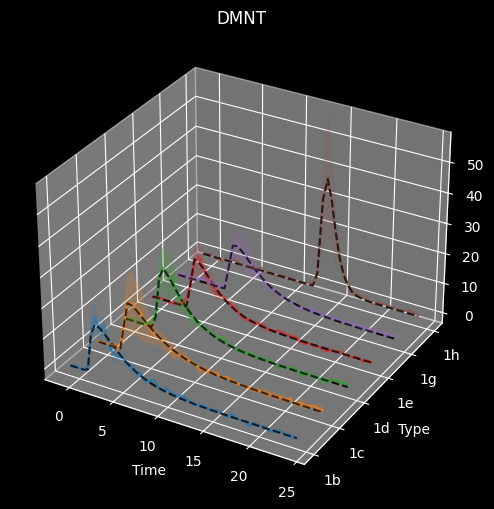

Saved 1479 rows to Submitted_results/Results_DMNT_time.csv


In [119]:
param_config = copy.deepcopy(param_config_DMNT)

comp = 'DMNT'
res = []
data = data_cir
for type in sorted(data.Type.unique()):
    if type not in ['a']:
        print(type)

        # Adjust the initial guess for the onset and mean times
        data_group = data[(data['Type'] == type) & (data['comp'] == comp)]
        time_shift = data_group['d1_time'].iloc[0] - data['d1_time'].min()

        param_local = copy.deepcopy(param_config)

        for key in ['t_onset', 't_mean']:
            param_local[key]['value'] = param_config[key]['value'] + time_shift
            param_local[key]['min']   = param_config[key]['min']   + time_shift
            param_local[key]['max']   = param_config[key]['max']   + time_shift

        individual_results = process_single_group(data, type, comp, param_local, lambda_prior=1)
        res.append(individual_results)

plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='d1_time')
#plot_fit_params_gamma(res, features='d1_time')

#plot_individual_fits(res,prior = True)# sep = True)
save_results_to_csv(res, 'Results_' + comp + '_time')

## OS - Oral Secretions

Fitting can be found in Figure 3

## Leaf Number

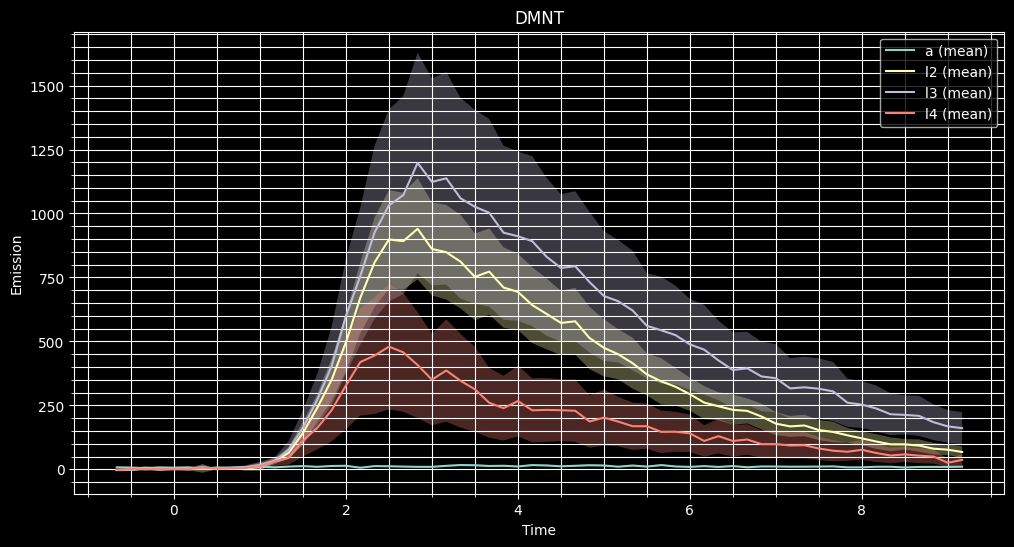

In [120]:
file_path = 'leaves_sub.csv'
dirty_data = pd.read_csv(file_path)
leaves = clean_and_reconstruct(dirty_data, norm = None)
plot_emission_data(leaves, plot_type='mean_error', comps = ['DMNT'])

In [121]:
param_config = copy.deepcopy(param_config_DMNT)

comp = 'DMNT'
res = Results_leaves = []
data = leaves
for type in sorted(data.Type.unique()):
    if type in ['l2', 'l3', 'l4']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 2)
        res.append(individual_results)

#check_double_parameters(res, features='d2_time', title='')
#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='Type')
#plot_fit_params_gamma(res, features='Type')

#plot_individual_fits(res, prior = True)# sep = True)
save_results_to_csv(res, 'Results_' + comp + '_leaves')

l2
Channel 65, Type l2, R² = 0.957
Channel 74, Type l2, R² = 0.987
Channel 79, Type l2, R² = 0.981
Channel 83, Type l2, R² = 0.981
Channel 91, Type l2, R² = 0.970
l3
Channel 66, Type l3, R² = 0.983
Channel 68, Type l3, R² = 0.968
Channel 73, Type l3, R² = 0.978
Channel 77, Type l3, R² = 0.980
Channel 90, Type l3, R² = 0.976
l4
Channel 72, Type l4, R² = 0.803
Channel 78, Type l4, R² = 0.948
Channel 80, Type l4, R² = 0.953
Channel 84, Type l4, R² = 0.923
Channel 85, Type l4, R² = 0.947
Saved 900 rows to Submitted_results/Results_DMNT_leaves.csv


## Genotype 

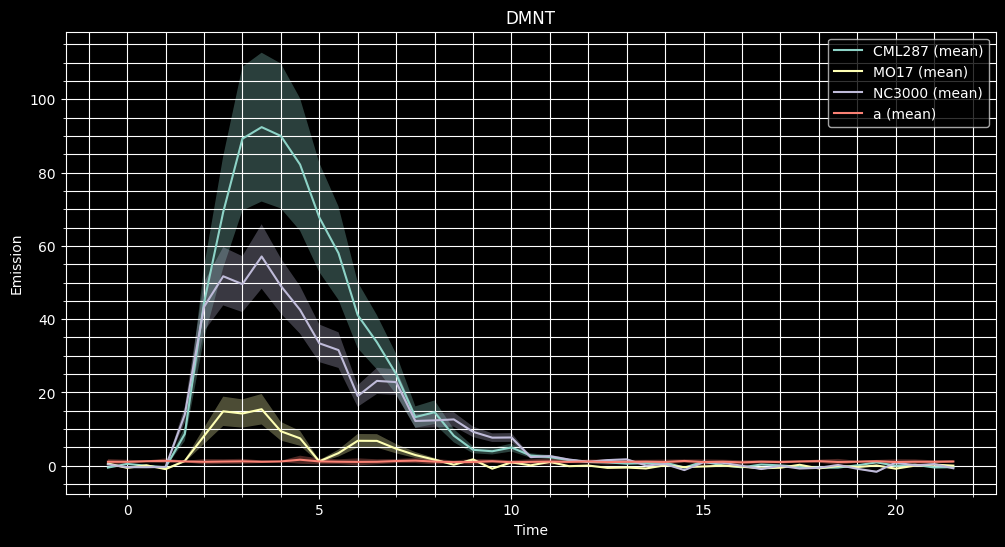

In [122]:
file_path = 'genotype_sub.csv'
dirty_data = pd.read_csv(file_path)

# Remove genotype specific backgrounds
CML287 = dirty_data[dirty_data['gt'] == 'CML287']
CML287 = clean_and_reconstruct(CML287, norm = 'Leaf3')
MO17 = dirty_data[dirty_data['gt'] == 'MO17']
MO17 = clean_and_reconstruct(MO17, norm = 'Leaf3')
NC300 = dirty_data[dirty_data['gt'] == 'NC3000']
NC300 = clean_and_reconstruct(NC300, norm = 'Leaf3')
# Rejoin into a single dataframe
geno_single = pd.concat([CML287, MO17, NC300], ignore_index=True)
plot_emission_data(geno_single, plot_type='mean_error', comps = ['DMNT'])

In [123]:
param_config = copy.deepcopy(param_config_DMNT)

comp = 'DMNT'
res = Results_geno_single = []
data = geno_single
for type in sorted(data.Type.unique()):
    if type in ['CML287', 'MO17', 'NC3000']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
        res.append(individual_results)

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='d1_time')
#plot_fit_params_gamma(res, features='d1_time')

#plot_individual_fits(res, prior = True)#, sep = True)
save_results_to_csv(res, 'Results_' + comp + '_Genotype')

CML287
Channel 29, Type CML287, R² = 0.991
Channel 35, Type CML287, R² = 0.991
Channel 42, Type CML287, R² = 0.989
Channel 72, Type CML287, R² = 0.984
MO17
Channel 26, Type MO17, R² = 0.703
Channel 49, Type MO17, R² = 0.736
Channel 53, Type MO17, R² = 0.924
Channel 91, Type MO17, R² = 0.785
NC3000
Channel 23, Type NC3000, R² = 0.991
Channel 32, Type NC3000, R² = 0.956
Channel 56, Type NC3000, R² = 0.939
Saved 495 rows to Submitted_results/Results_DMNT_Genotype.csv


# Figure 3: OS – All Compounds

In [130]:
file_path = 'os_with_sub.csv'
dirty_data = pd.read_csv(file_path)
os_with = clean_and_reconstruct(dirty_data, norm = 'Leaf3')

file_path = 'os_without_sub.csv'
dirty_data = pd.read_csv(file_path)
os_without = clean_and_reconstruct(dirty_data, norm = 'Leaf3')

os_single = pd.concat([os_with, os_without], ignore_index=True)

## DMNT

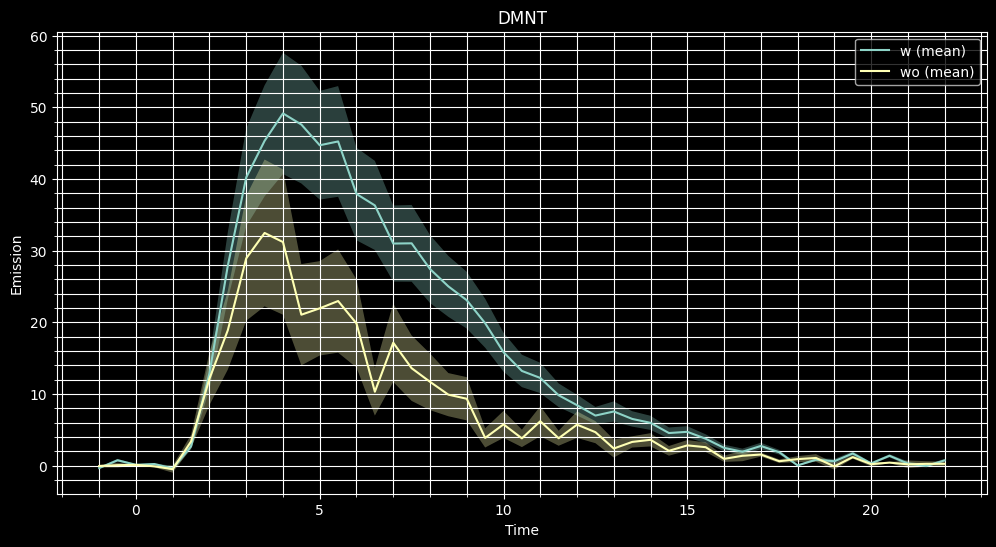

In [131]:
plot_emission_data(os_single, plot_type='mean_error', comps = ['DMNT'], types = ['w', 'wo'])

In [132]:
param_config = copy.deepcopy(param_config_DMNT)

comp = 'DMNT'
res = []
data = os_single
for type in sorted(data.Type.unique()):
    if type in ['wo', 'w']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
        res.append(individual_results)

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='d1_time')
#plot_fit_params_gamma(res, features='d1_time')

#plot_individual_fits(res, prior = True)
save_results_to_csv(res, 'Results_' + comp + '_Single_OS')

w
Channel 54, Type w, R² = 0.976
Channel 62, Type w, R² = 0.943
Channel 67, Type w, R² = 0.973
Channel 86, Type w, R² = 0.985
Channel 95, Type w, R² = 0.982
wo
Channel 60, Type wo, R² = 0.886
Channel 78, Type wo, R² = 0.723
Channel 83, Type wo, R² = 0.963
Channel 90, Type wo, R² = 0.707
Channel 101, Type wo, R² = 0.952
Saved 470 rows to Submitted_results/Results_DMNT_Single_OS.csv


## indole

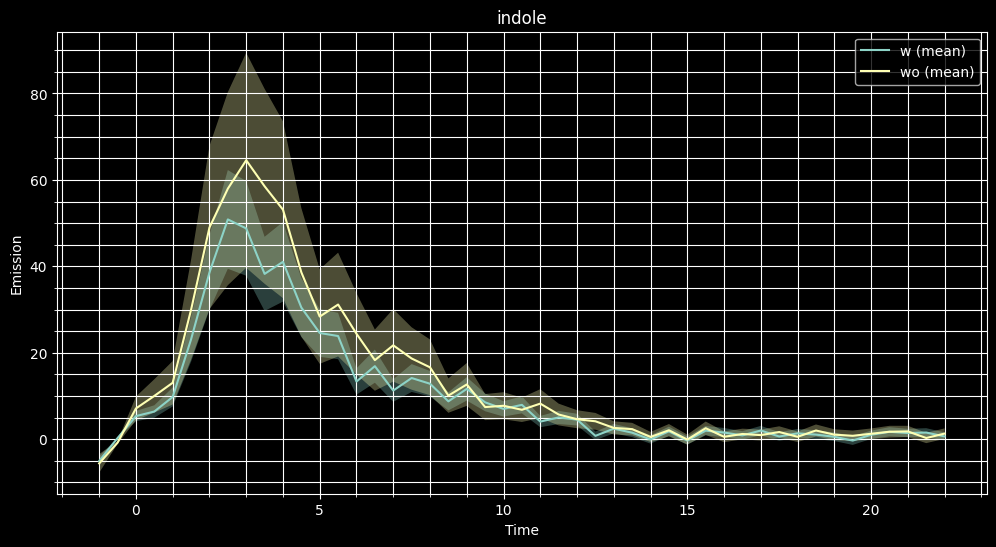

In [133]:
plot_emission_data(os_single, plot_type='mean_error', comps = ['indole'], types = ['w', 'wo'])

In [136]:
param_config = copy.deepcopy(param_config_indole)

comp = 'indole'
res = []
data = os_single
for type in sorted(data.Type.unique()):
    if type in ['wo', 'w']:
        print(type)
        print()
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
        res.append(individual_results)

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='d1_time')
#plot_fit_params_gamma(res, features='d1_time')

#plot_individual_fits(res, prior = True)#, sep = True)
save_results_to_csv(res, 'Results_' + comp + '_Single_OS')

w

Channel 54, Type w, R² = 0.804
Channel 62, Type w, R² = 0.939
Channel 67, Type w, R² = 0.847
Channel 86, Type w, R² = 0.953
Channel 95, Type w, R² = 0.963
wo

Channel 60, Type wo, R² = 0.901
Channel 78, Type wo, R² = 0.802
Channel 83, Type wo, R² = 0.950
Channel 90, Type wo, R² = 0.933
Channel 101, Type wo, R² = 0.966
Saved 470 rows to Submitted_results/Results_indole_Single_OS.csv


## TMTT

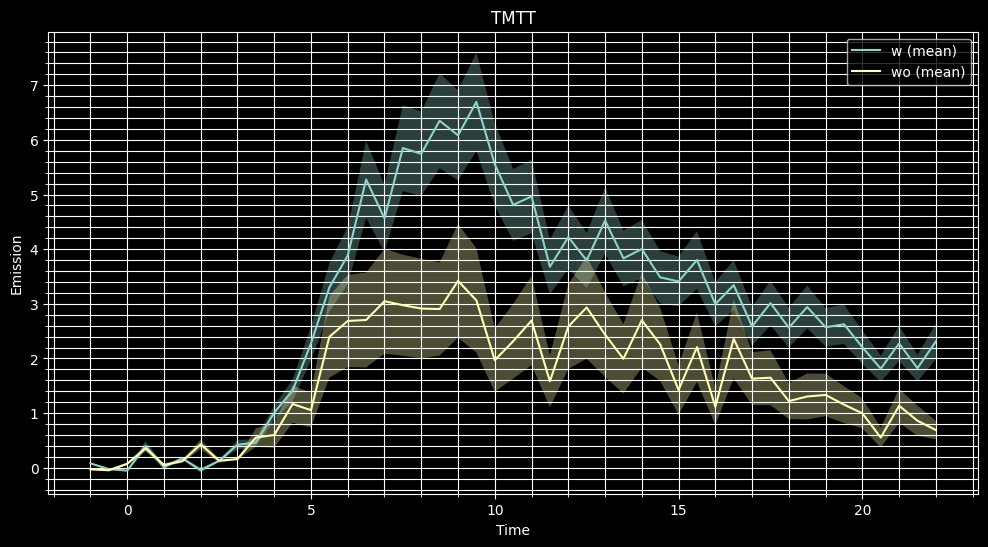

In [137]:
plot_emission_data(os_single, plot_type='mean_error', comps = ['TMTT'], types = ['w', 'wo'])

In [138]:
param_config = copy.deepcopy(param_config_TMTT)

comp = 'TMTT'
res = []
data = os_single
for type in sorted(data.Type.unique()):
    if type in ['wo', 'w']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
        res.append(individual_results)

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='d1_time')
#plot_fit_params_gamma(res, features='d1_time')

#plot_individual_fits(res, prior = True)#, sep = True)
#Remove channel 90
save_results_to_csv(res, 'Results_' + comp + '_Single_OS')

w
Channel 54, Type w, R² = 0.888
Channel 62, Type w, R² = 0.763
Channel 67, Type w, R² = 0.797
Channel 86, Type w, R² = 0.800
Channel 95, Type w, R² = 0.905
wo
Channel 60, Type wo, R² = 0.556
Channel 78, Type wo, R² = 0.456
Channel 83, Type wo, R² = 0.755
Channel 90, Type wo, R² = 0.475
Channel 101, Type wo, R² = 0.797
Saved 470 rows to Submitted_results/Results_TMTT_Single_OS.csv


## Sesq

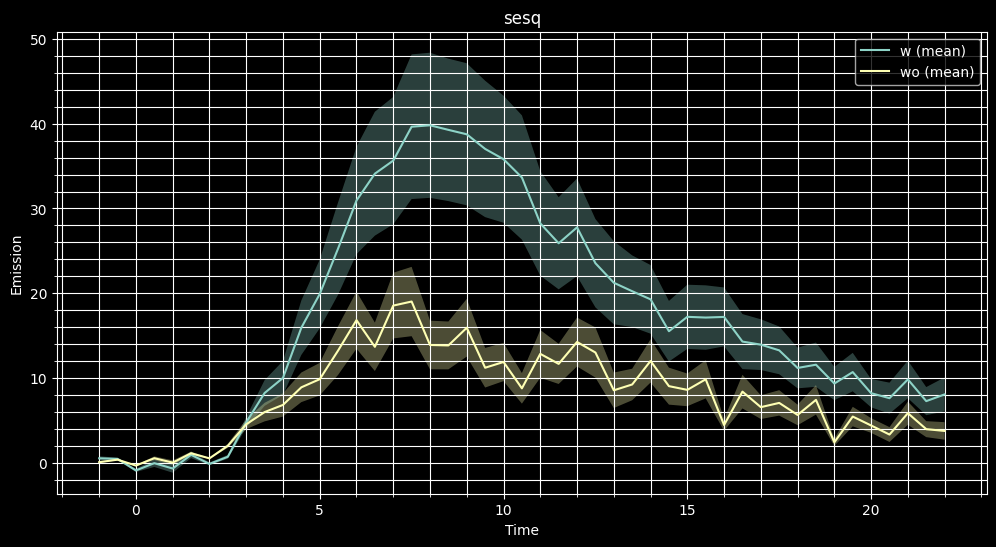

In [139]:
plot_emission_data(os_single, plot_type='mean_error', comps = ['sesq'], types = ['w', 'wo'])

In [140]:
param_config = copy.deepcopy(param_config_sesq)

comp = 'sesq'
res = []
data = os_single
for type in sorted(data.Type.unique()):
    if type in ['wo', 'w']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
        res.append(individual_results)

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='d1_time')
#plot_fit_params_gamma(res, features='d1_time')

#plot_individual_fits(res, prior = True)#, sep = True)
save_results_to_csv(res, 'Results_' + comp + '_Single_OS')

w
Channel 54, Type w, R² = 0.951
Channel 62, Type w, R² = 0.867
Channel 67, Type w, R² = 0.950
Channel 86, Type w, R² = 0.955
Channel 95, Type w, R² = 0.933
wo
Channel 60, Type wo, R² = 0.731
Channel 78, Type wo, R² = 0.619
Channel 83, Type wo, R² = 0.756
Channel 90, Type wo, R² = 0.629
Channel 101, Type wo, R² = 0.690
Saved 470 rows to Submitted_results/Results_sesq_Single_OS.csv


## mono

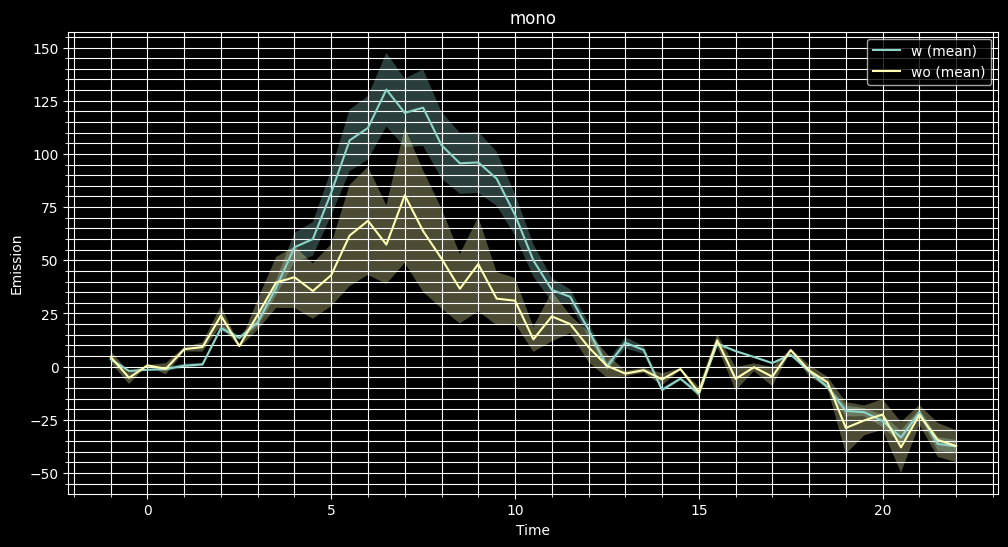

In [141]:
plot_emission_data(os_single, plot_type='mean_error', comps = ['mono'], types = ['w', 'wo'])

In [142]:
param_config = copy.deepcopy(param_config_mono)

comp = 'mono'
res = []
data = os_single
for type in sorted(data.Type.unique()):
    if type in ['wo','w']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
        res.append(individual_results)

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='d1_time')
#plot_fit_params_gamma(res, features='d1_time')

#plot_individual_fits(res, prior = True)

save_results_to_csv(res, 'Results_' + comp + '_Single_OS') #Channel 90 removed from MS due to poor data quality

w
Channel 54, Type w, R² = 0.890
Channel 62, Type w, R² = 0.861
Channel 67, Type w, R² = 0.876
Channel 86, Type w, R² = 0.906
Channel 95, Type w, R² = 0.857
wo
Channel 60, Type wo, R² = 0.762
Channel 78, Type wo, R² = 0.527
Channel 83, Type wo, R² = 0.766
Channel 90, Type wo, R² = 0.331
Channel 101, Type wo, R² = 0.719
Saved 470 rows to Submitted_results/Results_mono_Single_OS.csv


# Figure 4 A-E: Triple Damage Experiments

## Functions for fitting and plotting Triple damage

In [48]:
def process_single_group_three(data, type_value, comp_value, param_config,
                               r_squared_limit=0.0,
                               lambda_prior=1):
    """
    Fit three gamma emission curves for a specific type and compound group.
    
    Args:
        data (DataFrame): Input dataset containing time-series emission data.
        type_value (str): Type label to filter.
        comp_value (str): Compound label to filter.
        param_config (dict): Parameter configuration with bounds and initial values.
        r_squared_limit (float): Minimum acceptable R² for accepting a fit.
        lambda_prior (float): Weight of the prior-curve loss term.
    
    Returns:
        list: Fitted results and metadata for all accepted channels.
    """

    data_group = data[(data['Type'] == type_value) & (data['comp'] == comp_value)]
    results = []

    def fit_emission_curve_three(time,
                                 emission_raw,
                                 emission_prior,
                                 param_config,
                                 delta_t1,
                                 delta_t2):

        cfg = copy.deepcopy(param_config)
        mask = time >= 0

        # ------------------------------------------------------------
        # Apply damage-time shifts to second and third gamma curves
        # ------------------------------------------------------------
        # Curve 2
        for name in ('t_onset2', 't_peak2', 't_mean2'):
            cfg[name]['value'] += delta_t1
            cfg[name]['min']   += delta_t1
            cfg[name]['max']   += delta_t1

        # Curve 3
        for name in ('t_onset3', 't_peak3', 't_mean3'):
            cfg[name]['value'] += delta_t1 + delta_t2
            cfg[name]['min']   += delta_t1 + delta_t2
            cfg[name]['max']   += delta_t1 + delta_t2

        # ------------------------------------------------------------
        # Parameter vector definition
        # ------------------------------------------------------------
        param_names = [
            'R_peak',  't_peak',  't_onset',  't_mean',
            'R_peak2', 't_peak2', 't_onset2', 't_mean2',
            'R_peak3', 't_peak3', 't_onset3', 't_mean3'
        ]

        initial_guess = []
        bounds_list = []
        for pname in param_names:
            entry = cfg[pname]
            initial_guess.append(entry['value'])
            bounds_list.append((entry['min'], entry['max']))

        bounds = Bounds(
            [lo for lo, _ in bounds_list],
            [hi for _, hi in bounds_list]
        )

        # ------------------------------------------------------------
        # Objective
        # ------------------------------------------------------------
        def objective(parameters):
            (
                E1,  tp1,  ton1,  tm1,
                E2,  tp2,  ton2,  tm2,
                E3,  tp3,  ton3,  tm3
            ) = parameters

            model1 = model_gamma(time[mask], E1, tp1, ton1, tm1)
            model2 = model_gamma(time[mask], E2, tp2, ton2, tm2)
            model3 = model_gamma(time[mask], E3, tp3, ton3, tm3)
            model_total = model1 + model2 + model3

            loss_fit = np.sum((model_total - emission_raw[mask])**2)
            loss_prior = np.sum((model_total - emission_prior[mask])**2)

            return loss_fit + lambda_prior * loss_prior

        # ------------------------------------------------------------
        # Constraints: monotonic order of onset, peak, mean
        # ------------------------------------------------------------
        constraints = [
            {'type': 'ineq', 'fun': lambda x: x[6]  - x[2]},   # t_onset2 ≥ t_onset1
            {'type': 'ineq', 'fun': lambda x: x[10] - x[6]},   # t_onset3 ≥ t_onset2
            {'type': 'ineq', 'fun': lambda x: x[5]  - x[1]},   # t_peak2 ≥ t_peak1
            {'type': 'ineq', 'fun': lambda x: x[9]  - x[5]},   # t_peak3 ≥ t_peak2
            {'type': 'ineq', 'fun': lambda x: x[7]  - x[3]},   # t_mean2 ≥ t_mean1
            {'type': 'ineq', 'fun': lambda x: x[11] - x[7]},   # t_mean3 ≥ t_mean2
        ]

        # ------------------------------------------------------------
        # Optimization
        # ------------------------------------------------------------
        best_parameters, success = run_de_then_slsqp(objective,
                                                     initial_guess,
                                                     bounds,
                                                     constraints)
        if not success:
            return None

        # ------------------------------------------------------------
        # Unpack fitted parameters
        # ------------------------------------------------------------
        fit_parameters = {p: best_parameters[i]
                             for i, p in enumerate(param_names)}

        # Model curves
        model_curve_1 = model_gamma(time, fit_parameters['R_peak'],  fit_parameters['t_peak'],  fit_parameters['t_onset'],  fit_parameters['t_mean'])
        model_curve_2 = model_gamma(time, fit_parameters['R_peak2'], fit_parameters['t_peak2'], fit_parameters['t_onset2'], fit_parameters['t_mean2'])
        model_curve_3 = model_gamma(time, fit_parameters['R_peak3'], fit_parameters['t_peak3'], fit_parameters['t_onset3'], fit_parameters['t_mean3'])
        
        # Integrals
        integral1 = total_integral_model_gamma(fit_parameters['R_peak'],  fit_parameters['t_peak'],  fit_parameters['t_onset'],  fit_parameters['t_mean'])
        integral2 = total_integral_model_gamma(fit_parameters['R_peak2'], fit_parameters['t_peak2'], fit_parameters['t_onset2'], fit_parameters['t_mean2'])
        integral3 = total_integral_model_gamma(fit_parameters['R_peak3'], fit_parameters['t_peak3'], fit_parameters['t_onset3'], fit_parameters['t_mean3'])
        
        # Durations
        duration1 = duration(fit_parameters['t_onset'],  fit_parameters['t_peak'],  fit_parameters['t_mean'])
        duration2 = duration(fit_parameters['t_onset2'], fit_parameters['t_peak2'], fit_parameters['t_mean2'])
        duration3 = duration(fit_parameters['t_onset3'], fit_parameters['t_peak3'], fit_parameters['t_mean3'])
        
        # Shapes
        shape1 = shape(fit_parameters['t_onset'],  fit_parameters['t_peak'],  fit_parameters['t_mean'])
        shape2 = shape(fit_parameters['t_onset2'], fit_parameters['t_peak2'], fit_parameters['t_mean2'])
        shape3 = shape(fit_parameters['t_onset3'], fit_parameters['t_peak3'], fit_parameters['t_mean3'])

        return {
            **{f"{k}_fit": v for k, v in fit_parameters.items()},
            'fitted_emission1': model_curve_1,
            'fitted_emission2': model_curve_2,
            'fitted_emission3': model_curve_3,
            'fitted_emission': model_curve_1 + model_curve_2 + model_curve_3,
            'prior': emission_prior,
            'time': time,
            'emission': emission_raw,
            'integral1': integral1,
            'integral2': integral2,
            'integral3': integral3,
            'duration1': duration1,
            'duration2': duration2,
            'duration3': duration3,
            'shape1': shape1,
            'shape2': shape2,
            'shape3': shape3
        }

    # ------------------------------------------------------------
    # Loop over channels
    # ------------------------------------------------------------
    for channel in data_group['Channel_number'].unique():
        channel_data = data_group[data_group['Channel_number'] == channel]

        time = channel_data['time'].values
        emission_raw = channel_data['Emission_RAW'].values
        emission_prior = channel_data['Emission'].values
        delta_t1 = channel_data['dt1'].iloc[0]
        delta_t2 = channel_data['dt2'].iloc[0]

        try:
            fit = fit_emission_curve_three(time,
                                           emission_raw,
                                           emission_prior,
                                           param_config,
                                           delta_t1,
                                           delta_t2)

        except Exception as e:
            print(f"Fitting failed for channel {channel}: {e}")
            continue

        # R²
        r2 = r_squared(emission_raw, fit['fitted_emission'])
        print(f'Channel {channel}, Type {type_value}, R² = {r2:.3f}')
        if r2 < r_squared_limit:
            print(f"Channel {channel} not accepted (R² below threshold).")
            continue

        # Integral sanity check
        if any(np.isnan([fit['integral1'], fit['integral2'], fit['integral3']])):
            print('Curve fit failed (NaN integral).')
            continue

        # ------------------------------------------------------------
        # Attach metadata
        # ------------------------------------------------------------
        fit.update({
            'Type': type_value,
            'comp': comp_value,
            'Channel_number': channel,
            'intensity1': channel_data['intensity1'].iloc[0],
            'intensity2': channel_data['intensity2'].iloc[0],
            'intensity3': channel_data['intensity3'].iloc[0],
            'Totalbio': channel_data['Totalbio'].iloc[0],
            'Leaf3': channel_data['Leaf3'].iloc[0],
            'd1_time': channel_data['d1_time'].iloc[0],
            'd2_time': channel_data['d2_time'].iloc[0],
            'd3_time': channel_data['d3_time'].iloc[0],
            'dt1': delta_t1,
            'dt2': delta_t2
        })

        results.append(fit)

    return results


In [49]:
# Plotting functions for the Triple results

def plot_fit_parameters_grid(result):
    """
    Plot fitted parameter values for triple-curve models across types.
    
    Args:
        result (list): Nested list of fit-result dictionaries.
    
    Returns:
        None: Displays plots.
    """

    flat = [d for group in result for d in group]
    df = pd.DataFrame(flat)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    fig.subplots_adjust(hspace=0.3, wspace=0.3)

    params = ['R_peak', 't_onset', 't_peak', 't_mean']
    markers = ['o', 's', 's']
    colors = ['tab:blue', 'tab:orange', 'tab:green']

    # Safe get with fallback to zero
    dt1 = df.get('dt1', pd.Series(0, index=df.index))
    dt2 = df.get('dt2', pd.Series(0, index=df.index))

    for ax, param in zip(axes.ravel(), params):
        grouped = df.groupby('Type')
        x = range(len(grouped))
        xticks = list(grouped.groups.keys())

        for i, suffix in enumerate(['_fit', '2_fit', '3_fit']):
            col = f"{param}{suffix}"
            if col in df.columns:
                values = df[col].copy()

                if param.startswith("t_"):
                    if suffix == '2_fit':
                        values -= dt1
                    elif suffix == '3_fit':
                        values -= (dt1 + dt2)
                    # '_fit' gets no adjustment

                df[f"{col}_adj"] = values
                mean = grouped[f"{col}_adj"].mean()
                std = grouped[f"{col}_adj"].std()

                ax.errorbar(x, mean, yerr=std, fmt=markers[i], capsize=4,
                            label=col, color=colors[i])

        ax.set_title(param)
        ax.set_xticks(x)
        ax.set_xticklabels(xticks)
        ax.legend()
        ax.minorticks_on()
        ax.grid()

    fig.suptitle('Fit Parameters by Type with Error Bars', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

def plot_derived_parameters_grid(result):
    """
    Plot derived triple-curve parameters across types with error bars.
    
    Args:
        result (list): Nested list of fit-result dictionaries.
    
    Returns:
        None: Displays plots.
    """

    flat = [d for group in result for d in group]
    df = pd.DataFrame(flat)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    fig.subplots_adjust(hspace=0.3, wspace=0.3)

    param_groups = [
        ('R_peak', ['R_peak_fit', 'R_peak2_fit', 'R_peak3_fit']),
        ('Integral', ['in1', 'in2', 'in3']),
        ('Duration', ['duration1', 'duration2', 'duration3']),
        ('Shape', ['shape1', 'shape2', 'shape3']),
    ]

    markers = ['o', 's', 's']
    colors = ['tab:blue', 'tab:orange', 'tab:green']

    grouped = df.groupby('Type')
    x = range(len(grouped))
    xticks = list(grouped.groups.keys())

    for ax, (title, cols) in zip(axes.ravel(), param_groups):
        for i, col in enumerate(cols):
            if col in df.columns:
                mean = grouped[col].mean()
                std = grouped[col].std()
                ax.errorbar(x, mean, yerr=std, fmt=markers[i], capsize=4,
                            label=col, color=colors[i])

        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels(xticks)
        ax.legend()
        ax.minorticks_on()
        ax.grid()

    fig.suptitle('Derived Parameters by Type with Error Bars', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## Fitting Triple Damage

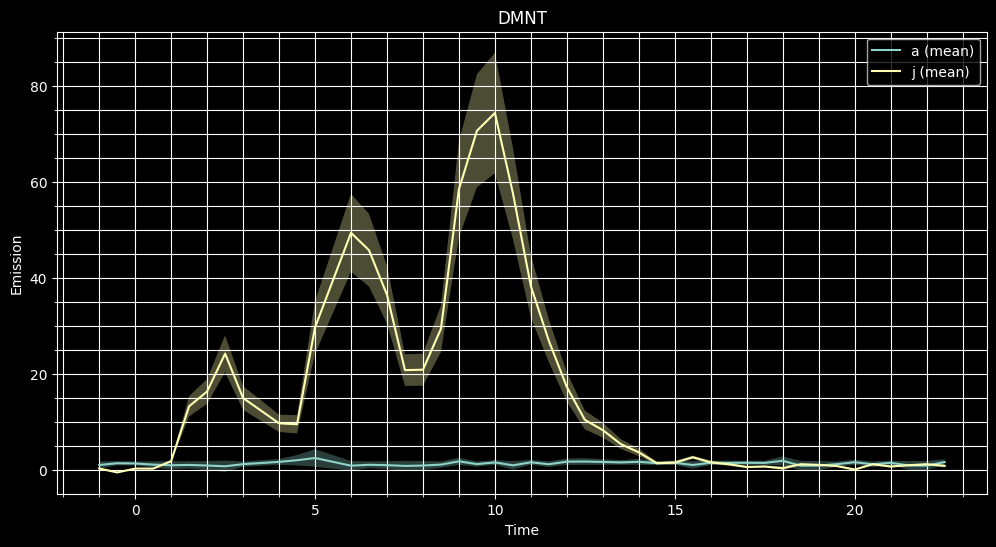

In [50]:
file_path = 'triple_sub.csv'
dirty_data = pd.read_csv(file_path)
triple = clean_and_reconstruct(dirty_data, norm = 'Leaf3')
plot_emission_data(triple, plot_type='mean_error', comps = ['DMNT'])

j
Channel 24, Type j, R² = 0.974
Channel 41, Type j, R² = 0.958
Channel 43, Type j, R² = 0.972
Channel 59, Type j, R² = 0.983
Channel 67, Type j, R² = 0.984
Channel 90, Type j, R² = 0.973


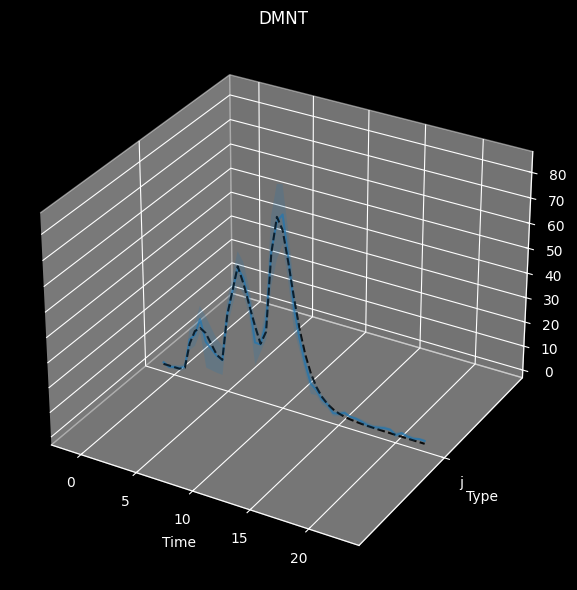

Saved 276 rows to Submitted_results/Results_DMNT_trip.csv


In [52]:
## Need to check and potentially change the parameter configuration.
    #'R_peak':   {'value': 25, 'min': 10, 'max': 50},
    #'t_peak':   {'value': 2.5, 'min': 1, 'max': 3},
    #'t_onset':  {'value': 1.1, 'min': 0, 'max': 5},
    #'t_mean':   {'value': 3.3, 'min': 3, 'max': 3.5},

param_config = {
    # Curve 1
    'R_peak':   {'value': 25, 'min': 10, 'max': 50},
    't_peak':   {'value': 2.5, 'min': 1, 'max': 3},
    't_onset':  {'value': 1.1, 'min': 0, 'max': 2},
    't_mean':   {'value': 3.3, 'min': 3, 'max': 3.5},
    
    # Curve 2
    'R_peak2':   {'value': 45, 'min': 15, 'max': 70},
    't_peak2':   {'value': 2.5, 'min': 1, 'max': 3},
    't_onset2':  {'value': 1.1, 'min': 0, 'max': 2}, #3.75
    't_mean2':   {'value': 3.55, 'min': 3, 'max': 3.8},
}

param_config3 = {
    # Curve 3
    'R_peak3':   {'value': 75, 'min': 20, 'max': 100},
    't_peak3':   {'value': 2.5, 'min': 1, 'max': 2.5},
    't_onset3':  {'value': 1.1, 'min': 0, 'max': 2},
    't_mean3':   {'value': 3.5, 'min': 3, 'max': 3.8},
}

comp = 'DMNT'
res = []
param_config = param_config | param_config3
data = triple
for type in sorted(data.Type.unique()):
    if type not in ['a']:
        print(type)
        individual_results = process_single_group_three(data, type, comp, param_config, lambda_prior=0)
        res.append(individual_results)


plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_parameters_grid(res)
#plot_derived_parameters_grid(res)

#plot_individual_fits_trip(res, prior = False, sep = True)

array_cols = [
            'time', 'emission', 'prior',
            'fitted_emission1', 'fitted_emission2', 'fitted_emission3', 'fitted_emission'
        ]
save_results_to_csv(res, 'Results_' + comp + '_trip', array_cols = array_cols)

# Figure 4F–I: Real Herbivore Damage

In [127]:
file_path = 'herbreal_sub.csv'
dirty_data = pd.read_csv(file_path)
single_herb = clean_and_reconstruct(dirty_data, norm = None)

## DMNT

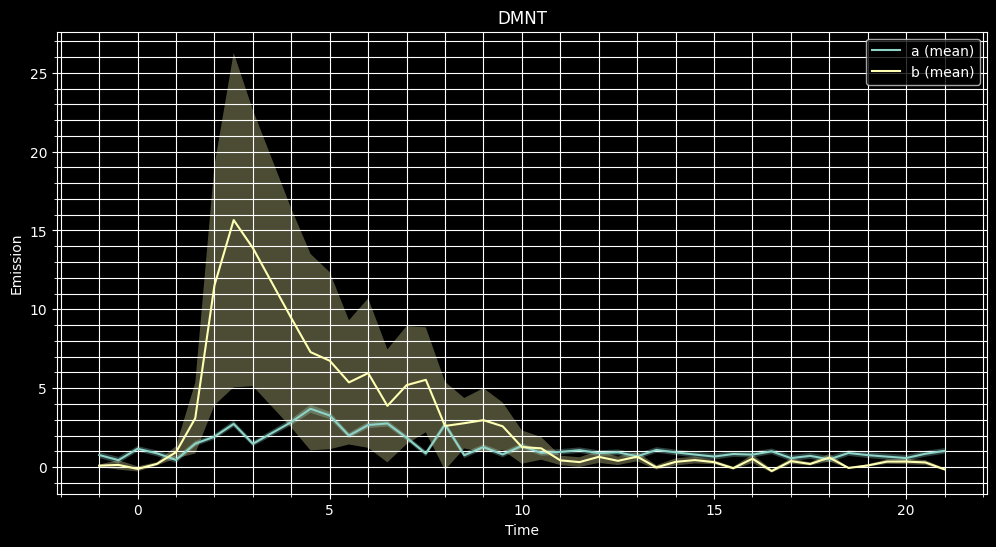

In [143]:
plot_emission_data(single_herb, plot_type='mean_error', comps = ['DMNT'])

In [144]:
param_config = copy.deepcopy(param_config_DMNT)

comp = 'DMNT'
res = []
data = single_herb
for type in sorted(data.Type.unique()):
    if type in ['b']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
        res.append(individual_results)

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='d1_time')
#plot_fit_params_gamma(res, features='d1_time')

#plot_individual_fits(res, prior = True) #, sep = True)

save_results_to_csv(res, 'Results_' + comp + '_single_herb')

b
Channel 60, Type b, R² = 0.718
Channel 62, Type b, R² = 0.597
Channel 67, Type b, R² = 0.781
Channel 73, Type b, R² = 0.819
Channel 77, Type b, R² = 0.971
Channel 86, Type b, R² = 0.937
Channel 90, Type b, R² = 0.880
Channel 92, Type b, R² = 0.754
Channel 102, Type b, R² = 0.920
Saved 396 rows to Submitted_results/Results_DMNT_single_herb.csv


## Indole

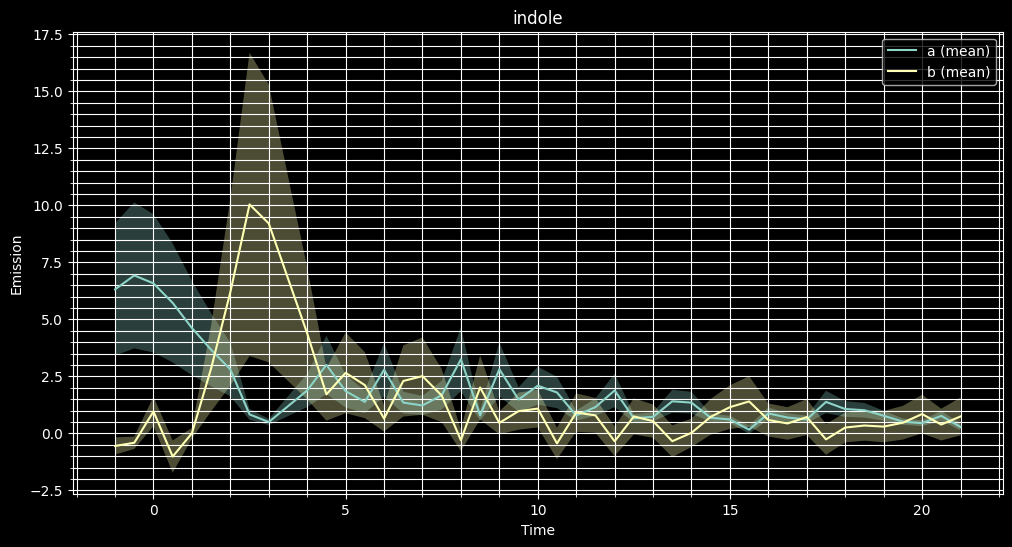

In [145]:
plot_emission_data(single_herb, plot_type='mean_error', comps = ['indole'])

In [146]:
param_config = copy.deepcopy(param_config_indole)

comp = 'indole'
res = []
data = single_herb
for type in sorted(data.Type.unique()):
    if type in ['b']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
        res.append(individual_results)

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='d1_time')
#plot_fit_params_gamma(res, features='d1_time')

#plot_individual_fits(res, prior = True)#, sep = True)
save_results_to_csv(res, 'Results_' + comp + '_single_herb') #Channel 62 removed from MS due to poor data quality

b
Channel 60, Type b, R² = 0.606
Channel 62, Type b, R² = 0.108
Channel 67, Type b, R² = 0.814
Channel 73, Type b, R² = 0.323
Channel 77, Type b, R² = 0.866
Channel 86, Type b, R² = 0.768
Channel 90, Type b, R² = 0.787
Channel 92, Type b, R² = 0.604
Channel 102, Type b, R² = 0.785
Saved 396 rows to Submitted_results/Results_indole_single_herb.csv


## TMTT

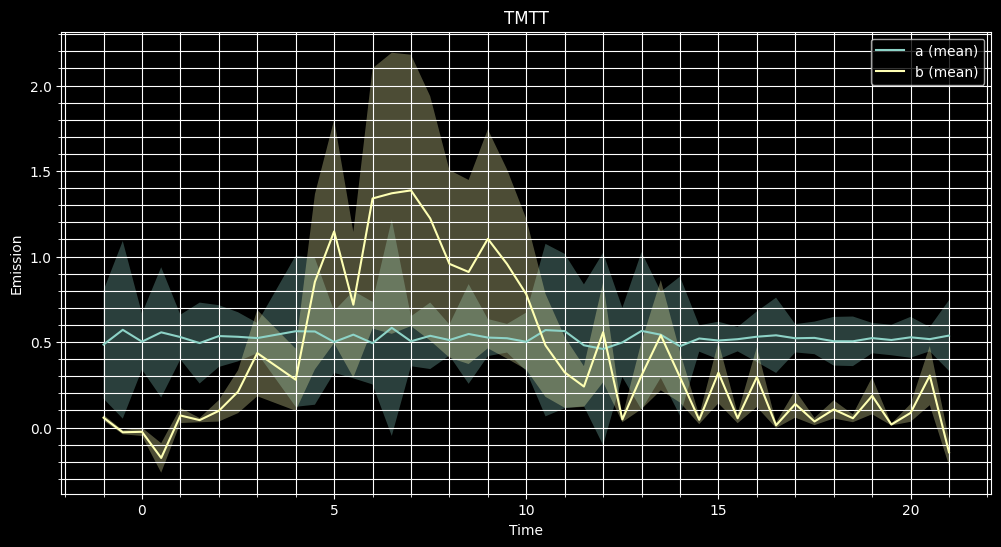

In [147]:
plot_emission_data(single_herb, plot_type='mean_error', comps = ['TMTT'])

In [148]:
param_config = copy.deepcopy(param_config_TMTT)

comp = 'TMTT'
res = []
data = single_herb
for type in sorted(data.Type.unique()):
    if type in ['b']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config,  lambda_prior = 1)
        res.append(individual_results)

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='d1_time')
#plot_fit_params_gamma(res, features='d1_time')

#plot_individual_fits(res, prior = True) #, sep = True)
save_results_to_csv(res, 'Results_' + comp + '_single_herb') #Channel 73 removed from MS due to poor data quality

b
Channel 60, Type b, R² = 0.259
Channel 62, Type b, R² = 0.217
Channel 67, Type b, R² = 0.494
Channel 73, Type b, R² = 0.059
Channel 77, Type b, R² = 0.600
Channel 86, Type b, R² = 0.748
Channel 90, Type b, R² = 0.281
Channel 92, Type b, R² = 0.240
Channel 102, Type b, R² = 0.658
Saved 396 rows to Submitted_results/Results_TMTT_single_herb.csv


## sesq

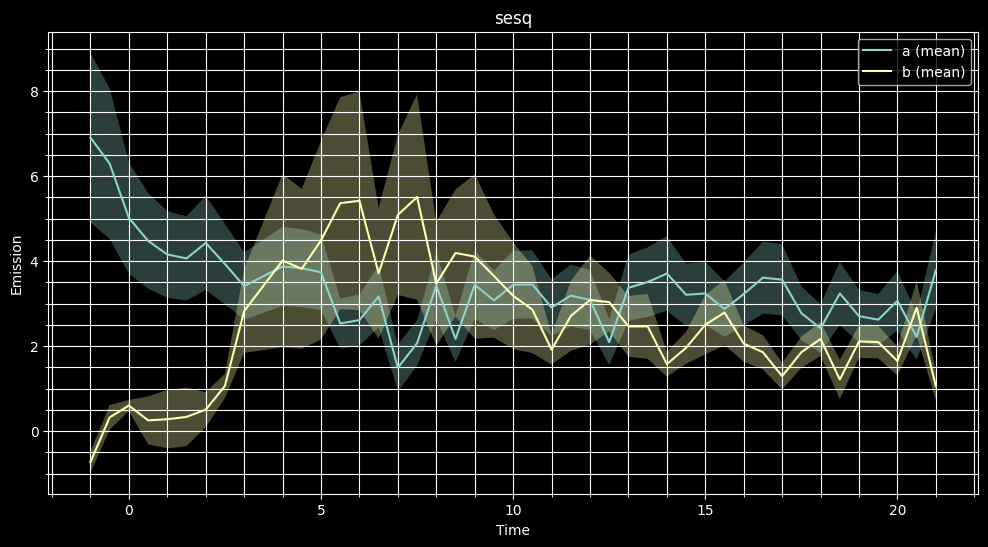

In [149]:
plot_emission_data(single_herb, plot_type='mean_error', comps = ['sesq'])

In [152]:
param_config = copy.deepcopy(param_config_sesq)

comp = 'sesq'
res = []
data = single_herb
for type in sorted(data.Type.unique()):
    if type in ['b']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config,  lambda_prior = 1)
        res.append(individual_results)

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='d1_time')
#plot_fit_params_gamma(res, features='d1_time')

#plot_individual_fits(res, prior = True) #, sep = True)
save_results_to_csv(res, 'Results_' + comp + '_single_herb') 

b
Channel 60, Type b, R² = 0.245
Channel 62, Type b, R² = 0.404
Channel 67, Type b, R² = 0.447
Channel 73, Type b, R² = -0.368
Channel 73 not accepted (R² below threshold).
Channel 77, Type b, R² = 0.754
Channel 86, Type b, R² = 0.877
Channel 90, Type b, R² = 0.253
Channel 92, Type b, R² = 0.333
Channel 102, Type b, R² = 0.636
Saved 352 rows to Submitted_results/Results_sesq_single_herb.csv


## mono

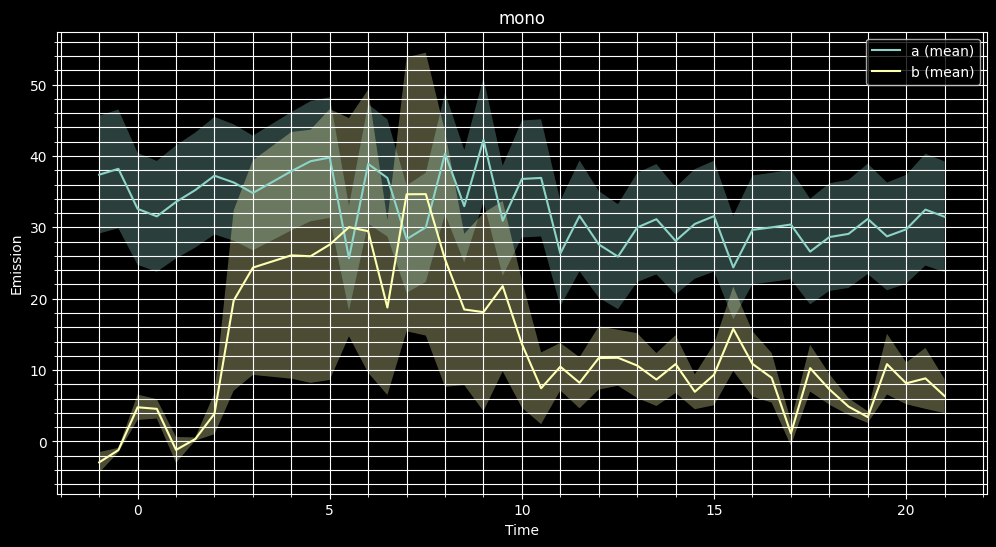

In [66]:
plot_emission_data(single_herb, plot_type='mean_error', comps = ['mono'])

In [67]:
param_config = copy.deepcopy(param_config_mono)

comp = 'mono'
res = []
data = single_herb
for type in sorted(data.Type.unique()):
    if type in ['b']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
        res.append(individual_results)

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='d1_time')
#plot_fit_params_gamma(res, features='d1_time')

#plot_individual_fits(res, prior = True)#, sep = True)
save_results_to_csv(res, 'Results_' + comp + '_single_herb') #Channel 73 and 90 removed from MS due to poor data quality

b
Channel 60, Type b, R² = 0.668
Channel 62, Type b, R² = 0.416
Channel 67, Type b, R² = 0.378
Channel 73, Type b, R² = -0.003
Channel 73 not accepted (R² below threshold).
Channel 77, Type b, R² = 0.793
Channel 86, Type b, R² = 0.907
Channel 90, Type b, R² = 0.083
Channel 92, Type b, R² = 0.155
Channel 102, Type b, R² = 0.492
Saved 352 rows to Submitted_results/Results_mono_single_herb.csv


# SI Figures

# Figure S1: GLV

In [68]:
file_path = 'glvkin_sub.csv'
dirty_data = pd.read_csv(file_path)

# Remove an obvious background from hexo
dirty_data.loc[dirty_data['comp'] == 'hexo', 'Emission'] -= 5
data_glvkin = clean_and_reconstruct(dirty_data, background = False, norm = None)

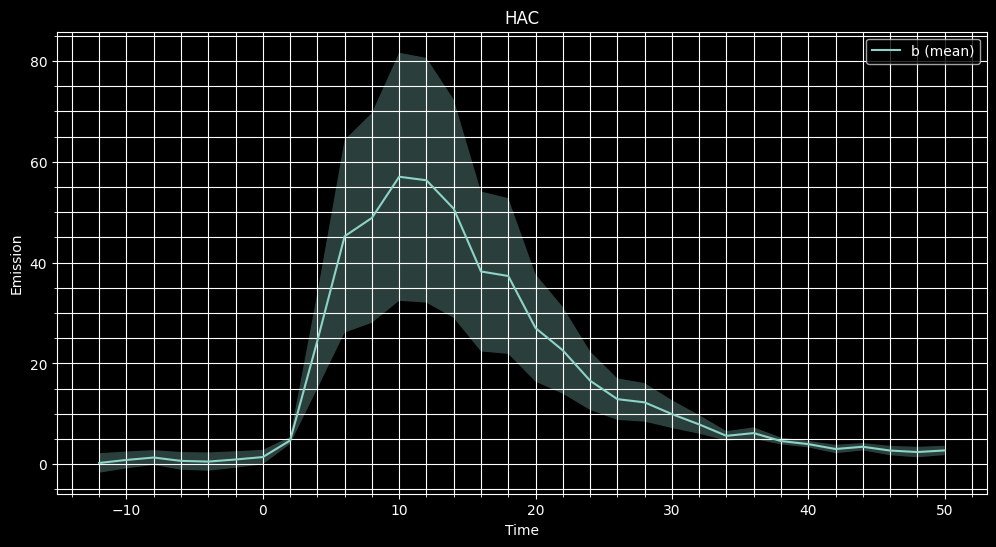

In [69]:
plot_emission_data(data_glvkin, plot_type='mean_error', comps = ['HAC'])

In [70]:
param_config= {
    #'R_peak': {'value': 20, 'min': 10, 'max':  100 },
    #'t_peak': {'value': 12, 'min': 4, 'max':  15 },
    't_onset': {'value': 1.5, 'min': 0, 'max':  20 },
    't_mean': {'value': 15.1, 'min': 1, 'max':  40 }
} 

comp = 'HAC'
res = []
data = data_glvkin
for type in sorted(data.Type.unique()):
    if type  in ['b']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
        res.append(individual_results)

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='intensity1')
#plot_fit_params_gamma(res, features='intensity1')

#plot_individual_fits(res, prior = True, sep = True)
save_results_to_csv(res, 'Results_HAC_HiRes')

b
Channel 12, Type b, R² = 0.982
Channel 13, Type b, R² = 0.982
Channel 18, Type b, R² = 0.977
Saved 96 rows to Submitted_results/Results_HAC_HiRes.csv


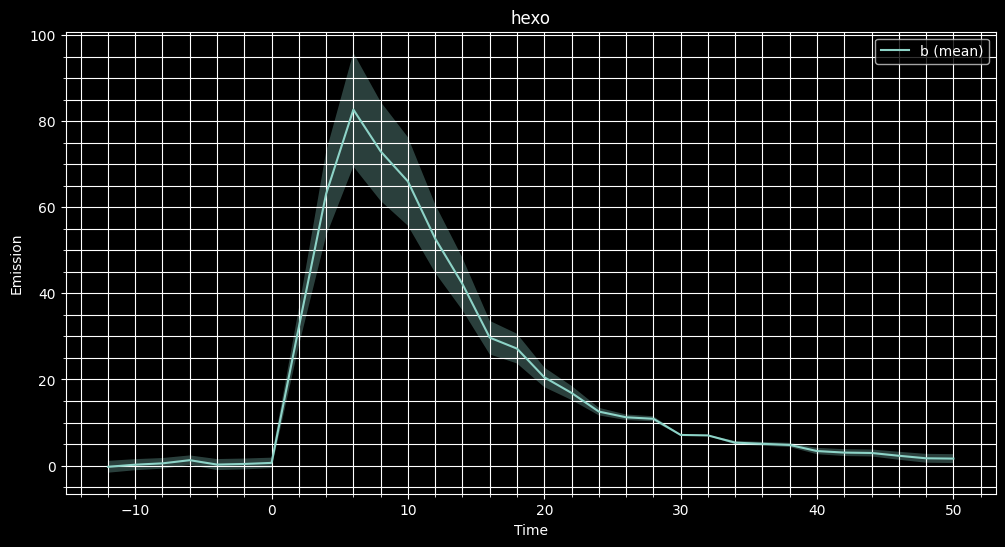

In [71]:
plot_emission_data(data_glvkin, plot_type='mean_error', comps = ['hexo'])

In [72]:
param_config= {
    #'R_peak': {'value': 70, 'min': 60, 'max':  110 },
    #'t_peak': {'value': 6, 'min': 4, 'max':  8 },
    't_onset': {'value': 1.5, 'min': 0.0, 'max':  20 },
    't_mean': {'value': 15.1, 'min': 1, 'max':  40 }
} 

comp = 'hexo'
res = Results_HAC_kin = []
data = data_glvkin
for type in sorted(data.Type.unique()):
    if type  in ['b']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 0)
        res.append(individual_results)

#check_double_parameters(res, features='d1_time', title='')
#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='intensity1')

#plot_individual_fits(res, prior = True, sep = True)
save_results_to_csv(res, 'Results_hexo_HiRes')

b
Channel 12, Type b, R² = 0.988
Channel 13, Type b, R² = 0.994
Channel 18, Type b, R² = 0.987
Saved 96 rows to Submitted_results/Results_hexo_HiRes.csv


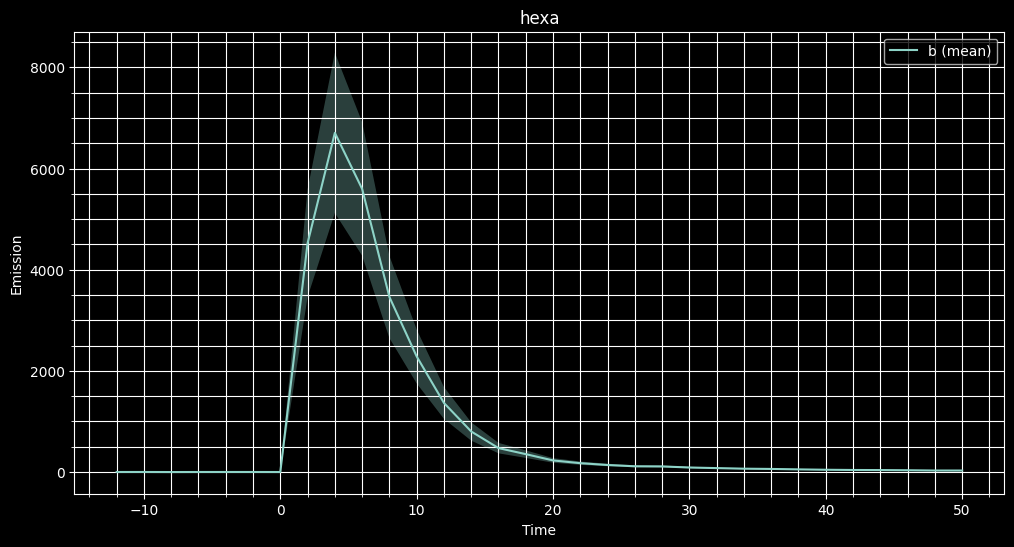

In [73]:
plot_emission_data(data_glvkin, plot_type='mean_error', comps = ['hexa'])

In [74]:
param_config= {
    #'R_peak': {'value': 5000, 'min': 5000, 'max':  8000 },
    #'t_peak': {'value': 4, 'min': 2, 'max':  6 },
    't_onset': {'value': 1.5, 'min': 0.0, 'max':  20 },
    't_mean': {'value': 15.1, 'min': 1, 'max':  40 }
} 

comp = 'hexa'
res = Results_HAC_kin = []
data = data_glvkin
for type in sorted(data.Type.unique()):
    if type  in ['b']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 0)
        res.append(individual_results)

#check_double_parameters(res, features='d1_time', title='')
#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='intensity1')
#plot_fit_params_gamma(res, features='intensity1')

#plot_individual_fits(res, prior = True, sep = True)
save_results_to_csv(res, 'Results_hexa_HiRes')

b
Channel 12, Type b, R² = 0.999
Channel 13, Type b, R² = 0.999
Channel 18, Type b, R² = 0.996
Saved 96 rows to Submitted_results/Results_hexa_HiRes.csv


# Figure S2: Gene

In [75]:
file_path = 'genexpression_real_sub.csv'
dirty_data = pd.read_csv(file_path)
gene = clean_and_reconstruct(dirty_data, norm = None)

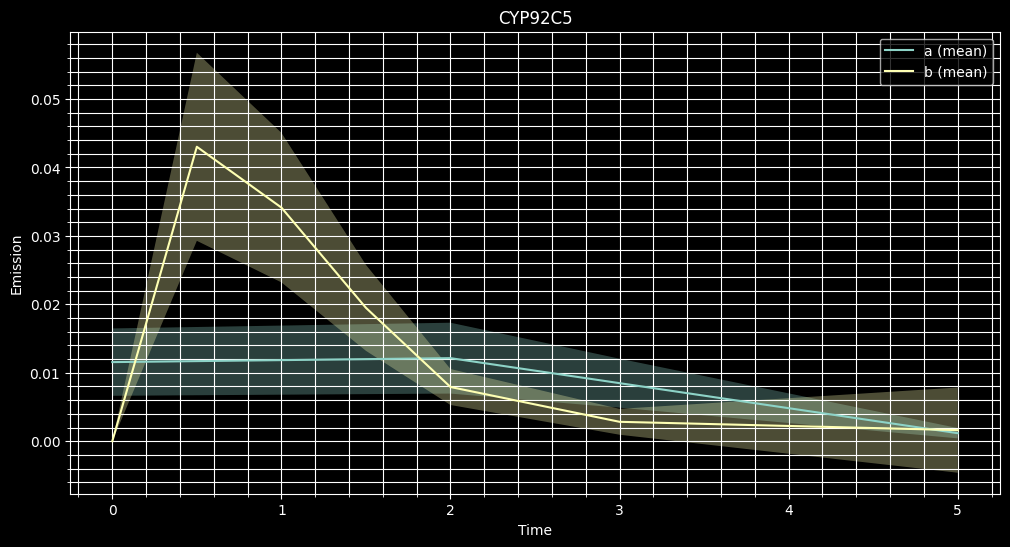

In [76]:
plot_emission_data(gene, plot_type='mean_error', comps = ['CYP92C5'])

b
Channel 1, Type b, R² = 0.933
Channel 2, Type b, R² = 0.876
Channel 3, Type b, R² = 0.961
Channel 4, Type b, R² = 0.330
Channel 5, Type b, R² = 0.754


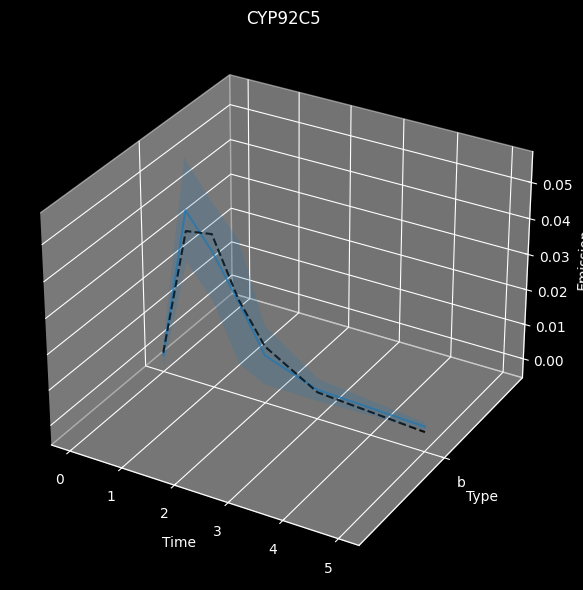

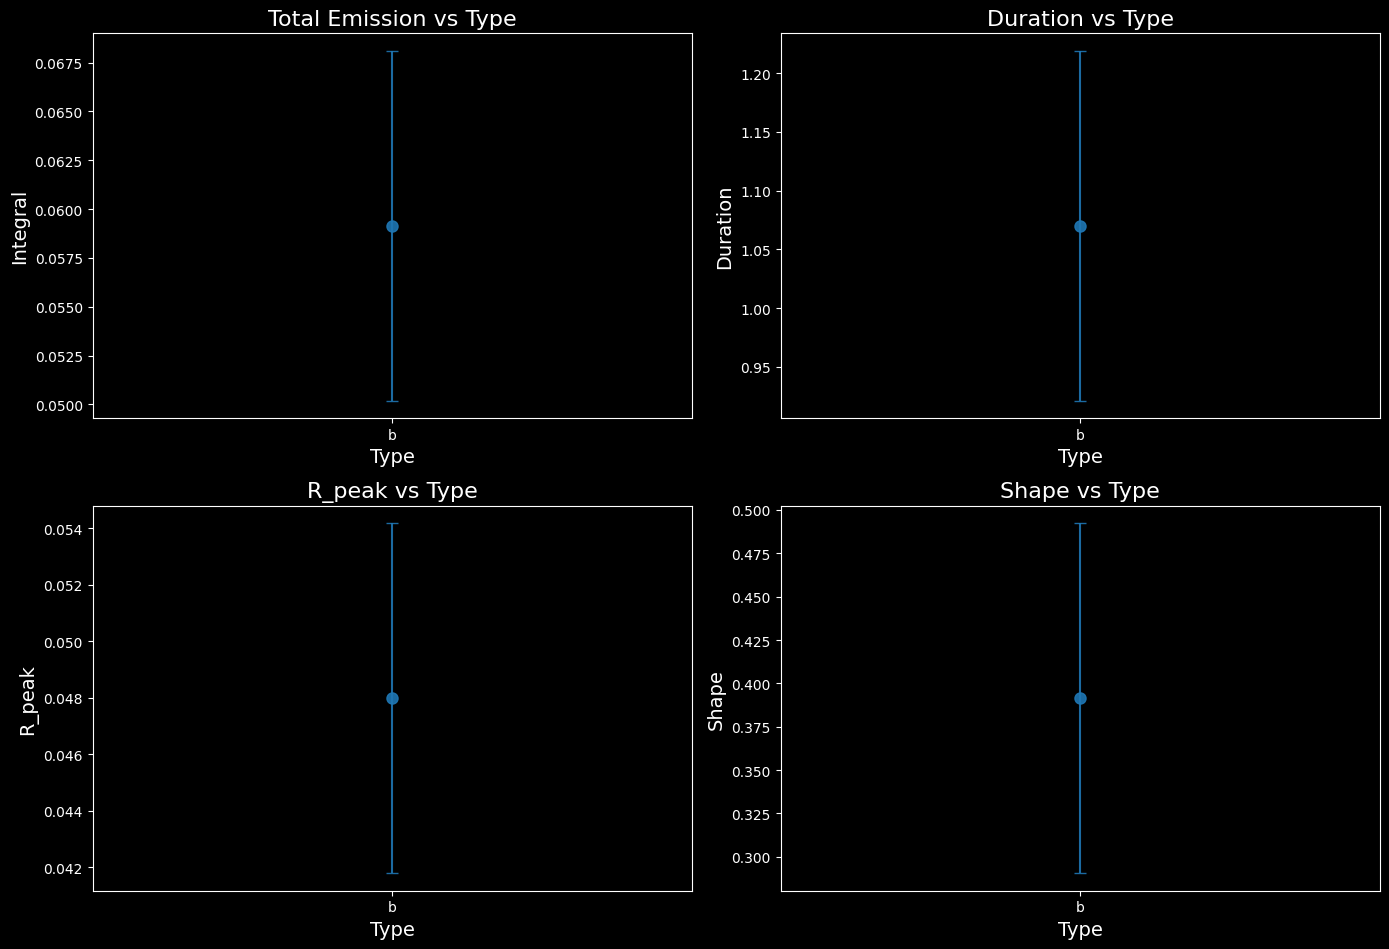

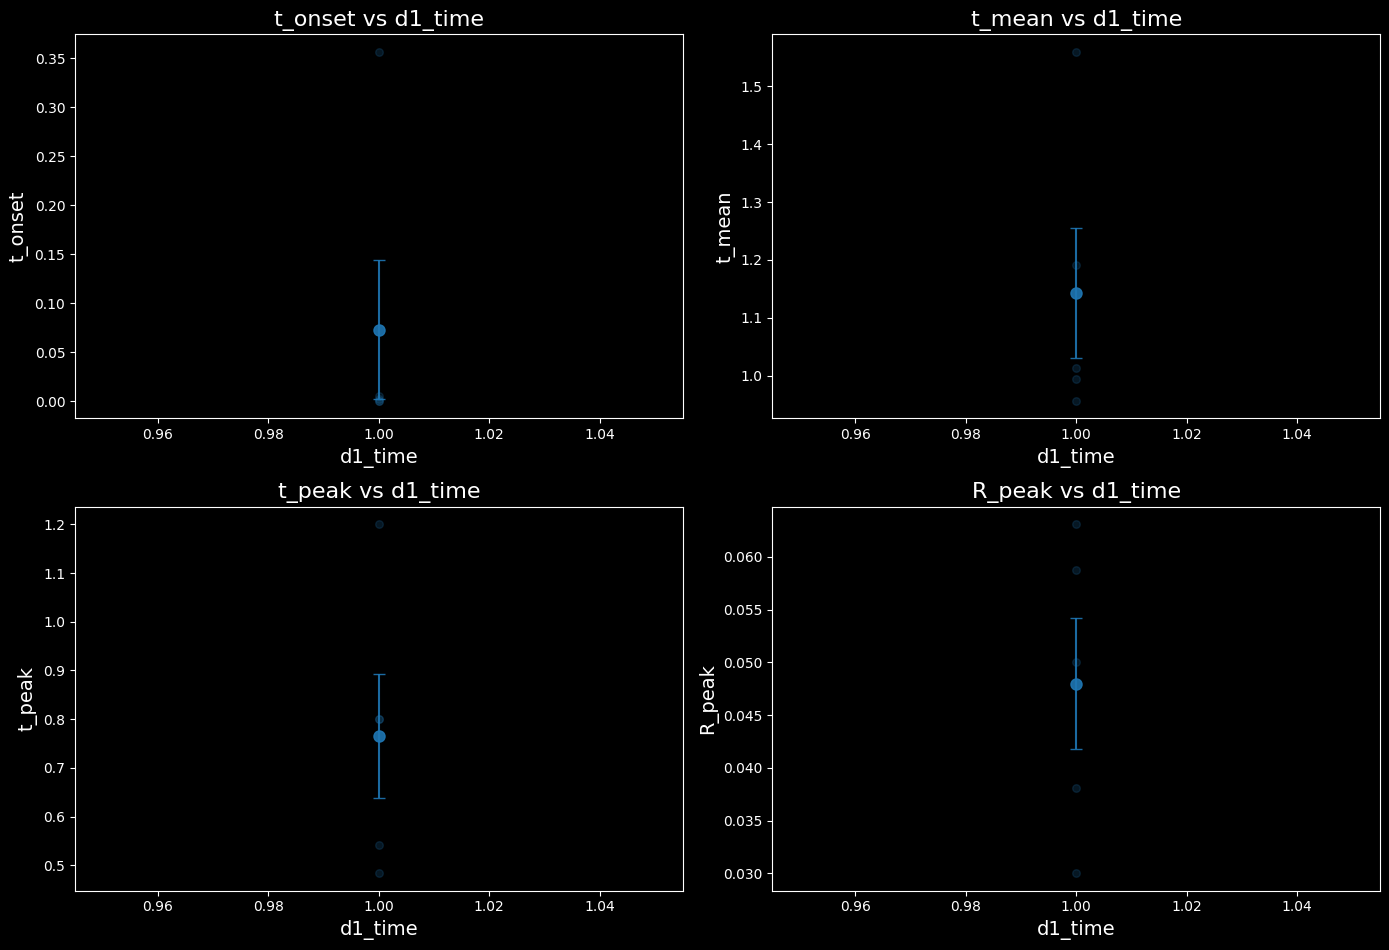

Saved 35 rows to Submitted_results/Results_CYP92C5_GeneExpression.csv


In [78]:
param_config = {
    #'R_peak': {'value': 0.04, 'min': 0.02, 'max':  0.06 },
    #'t_peak': {'value': 0.3, 'min': 0.21, 'max':  0.6 },
    't_onset': {'value': 0.12, 'min': 0, 'max':  2 },
    't_mean':  {'value': 2, 'min': 0.1, 'max':  5 }
} 

comp = 'CYP92C5'
res = []
data = gene
for type in sorted(data.Type.unique()):
    if type in ['b']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
        res.append(individual_results)

plot_3d_mean_fitting_results_by_type(res, title = comp)
plot_fit_results_gamma(res, features='Type')
plot_fit_params_gamma(res, features='d1_time')

#plot_individual_fits(res, prior = True)#, sep = True)
save_results_to_csv(res, 'Results_' + comp + '_GeneExpression') #Channel 4 removed from MS due to poor fitting

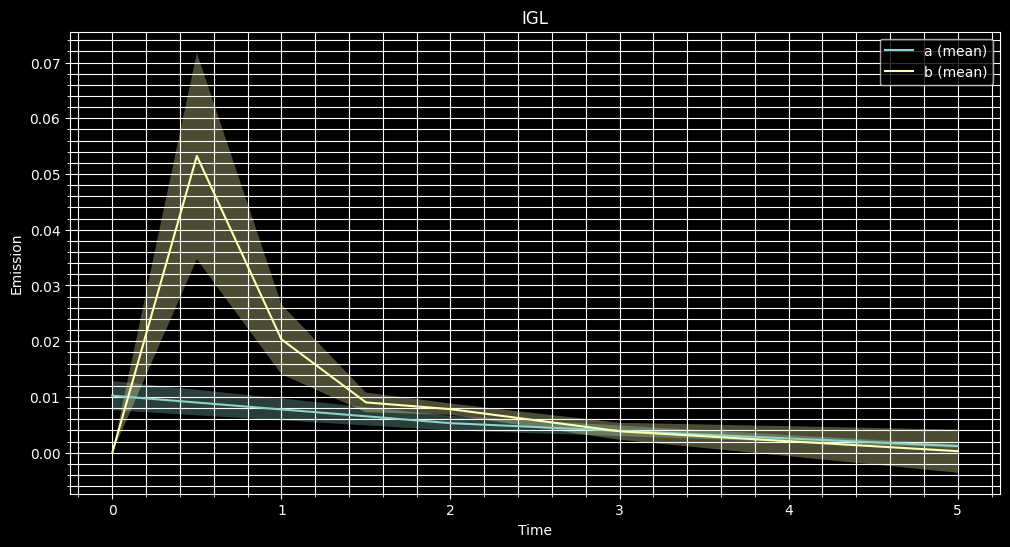

In [79]:
plot_emission_data(gene, plot_type='mean_error', comps = ['IGL'])

In [81]:
param_config = {
    #'R_peak': {'value': 0.04, 'min': 0.02, 'max':  0.06 },
    #'t_peak': {'value': 0.3, 'min': 0.21, 'max':  0.6 },
    't_onset': {'value': 0.12, 'min': 0, 'max':  2 },
    't_mean':  {'value': 2, 'min': 0.1, 'max':  5 }
} 

comp = 'IGL'
res = []
data = gene
for type in sorted(data.Type.unique()):
    if type in ['b']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
        res.append(individual_results)

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='Type')
#plot_fit_params_gamma(res,  features='d1_time')

#plot_individual_fits(res, prior = True)#, sep = True)
save_results_to_csv(res, 'Results_' + comp + '_GeneExpression')

b
Channel 1, Type b, R² = 0.903
Channel 2, Type b, R² = 0.895
Channel 3, Type b, R² = 0.945
Channel 4, Type b, R² = 0.938
Channel 5, Type b, R² = 0.956
Saved 35 rows to Submitted_results/Results_IGL_GeneExpression.csv


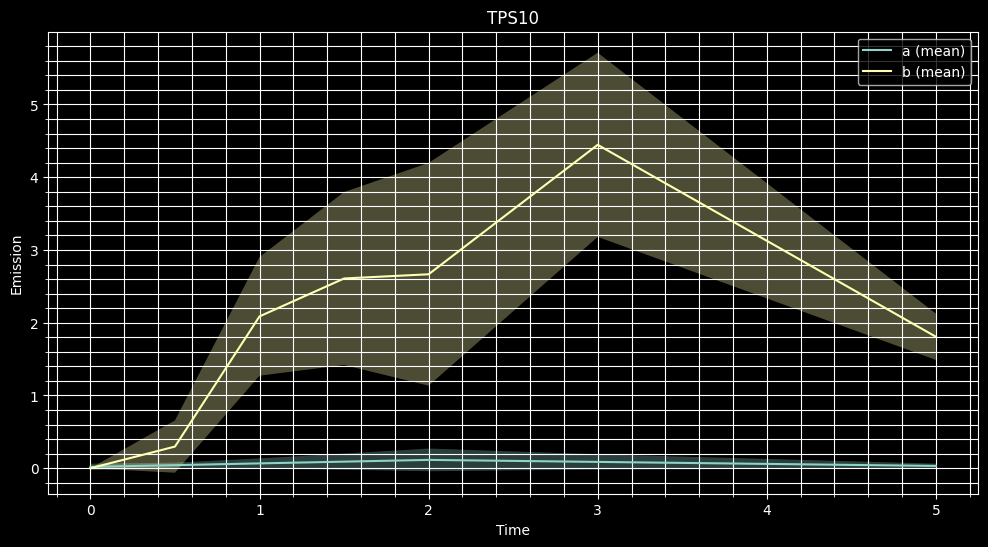

In [82]:
plot_emission_data(gene, plot_type='mean_error', comps = ['TPS10'])

b
Channel 1, Type b, R² = 0.718
Channel 2, Type b, R² = 0.889
Channel 3, Type b, R² = 0.891
Channel 4, Type b, R² = 0.685
Channel 5, Type b, R² = 0.437


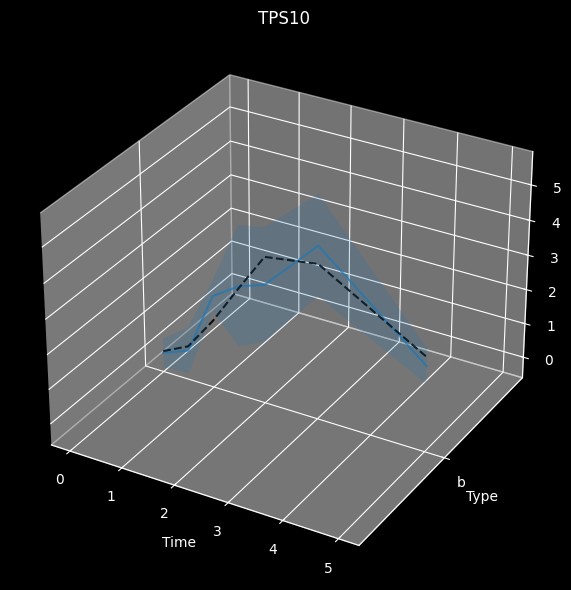

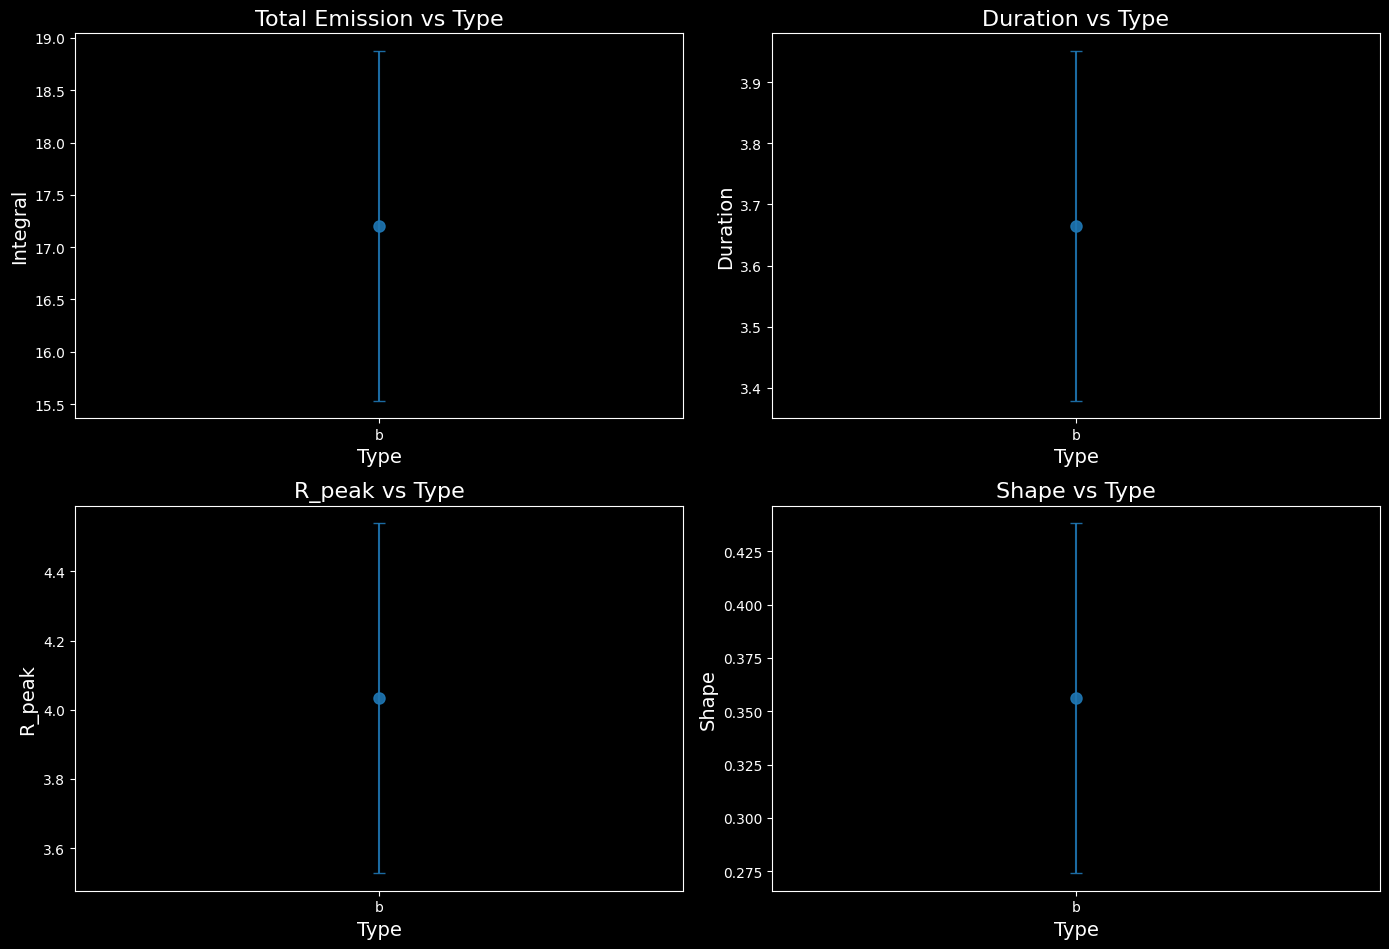

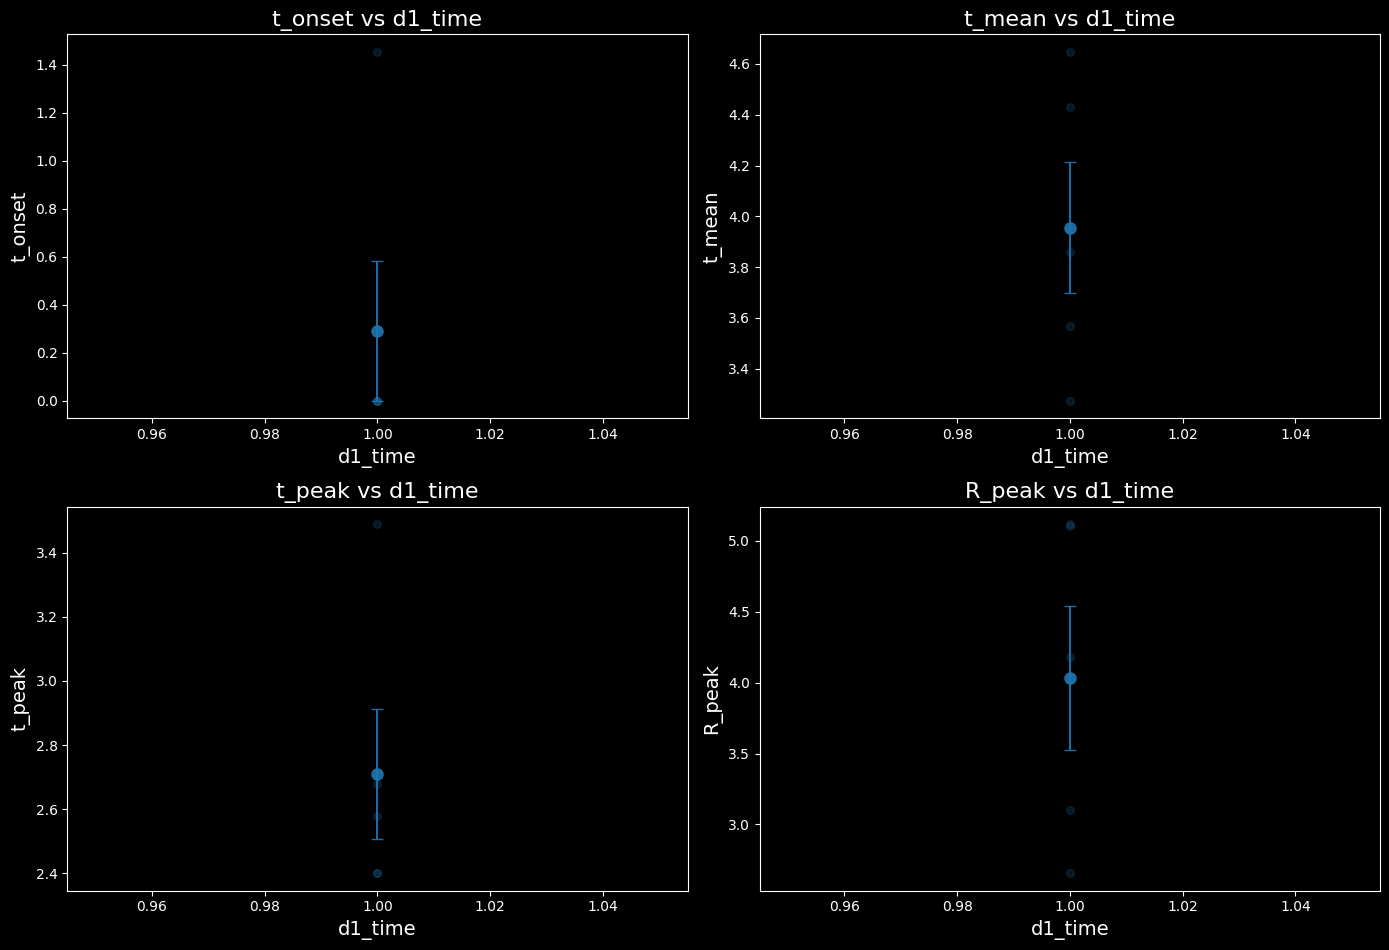

Saved 35 rows to Submitted_results/Results_TPS10_GeneExpression.csv


In [84]:
param_config = {
    #'R_peak': {'value': 5, 'min': 3, 'max':  6 },
    #'t_peak': {'value': 3, 'min': 2, 'max':  5 },
    't_onset': {'value': 0.12, 'min': 0, 'max':  2 },
    't_mean':  {'value': 2, 'min': 0.1, 'max':  5 }
} 

comp = 'TPS10'
res = []
data = gene
for type in sorted(data.Type.unique()):
    if type in ['b']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config,  lambda_prior = 1)
        res.append(individual_results)

plot_3d_mean_fitting_results_by_type(res, title = comp)
plot_fit_results_gamma(res, features='Type')
plot_fit_params_gamma(res, features='d1_time')

#plot_individual_fits(res, prior = True)# sep = True)
save_results_to_csv(res, 'Results_' + comp + '_GeneExpression') #Channel 1 and 5 removed from MS due to poor fitting

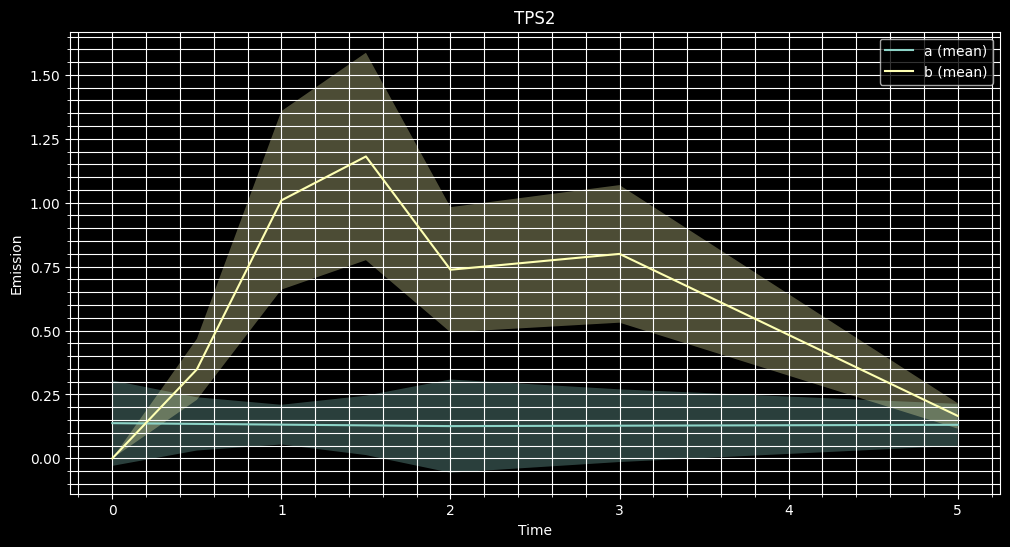

In [85]:
plot_emission_data(gene, plot_type='mean_error', comps = ['TPS2'])

In [86]:
param_config = {
    #'R_peak': {'value': 0.6, 'min': 0.4, 'max':  1.8 },
    #'t_peak': {'value': 2, 'min': 0.8, 'max':  2 },
    't_onset': {'value': 0.12, 'min': 0, 'max':  2 },
    't_mean':  {'value': 2, 'min': 0.1, 'max':  5 }
} 


comp = 'TPS2'
res = []
data = gene
for type in sorted(data.Type.unique()):
    if type in ['b']:
        print(type)
        individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
        res.append(individual_results)

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='Type')
#plot_fit_params_gamma(res, features='d1_time')

#plot_individual_fits(res, prior = True)#, sep = True)
save_results_to_csv(res, 'Results_' + comp + '_GeneExpression') #Channel 5 removed from MS due to poor fitting

b
Channel 1, Type b, R² = 0.775
Channel 2, Type b, R² = 0.467
Channel 3, Type b, R² = 0.814
Channel 4, Type b, R² = 0.609
Channel 5, Type b, R² = 0.373
Saved 35 rows to Submitted_results/Results_TPS2_GeneExpression.csv


# Figure S3: Model Test, measurement time

In [87]:
file_path = 'os_with_sub.csv'
dirty_data = pd.read_csv(file_path)
os_with = clean_and_reconstruct(dirty_data, norm = 'Leaf3')

In [88]:
new_dfs = []
next_channel = os_with["Channel_number"].max() + 1

filtered = os_with[os_with["Type"] != "a"]

for perc in range(10, 89, 1):
    for ch, df_ch in filtered.groupby("Channel_number"):
        # Calculate how many rows to keep
        keep_n = int(len(df_ch) * (100 - perc) / 100)

        # Take only the first part of the data (truncate the end)
        df_trunc = df_ch.sort_values("time").iloc[:keep_n].copy()
        
        # Assign new channel number
        df_trunc["Channel_number"] = next_channel
        next_channel += 1
        
        # Modify intensity1 and Type
        df_trunc["intensity1"] = df_trunc["intensity1"] + perc
        df_trunc["Type"] = df_trunc["Type"] + str(perc)
        
        new_dfs.append(df_trunc)

# Combine original + truncated copies
os_shortened = pd.concat([filtered] + new_dfs, ignore_index=True)


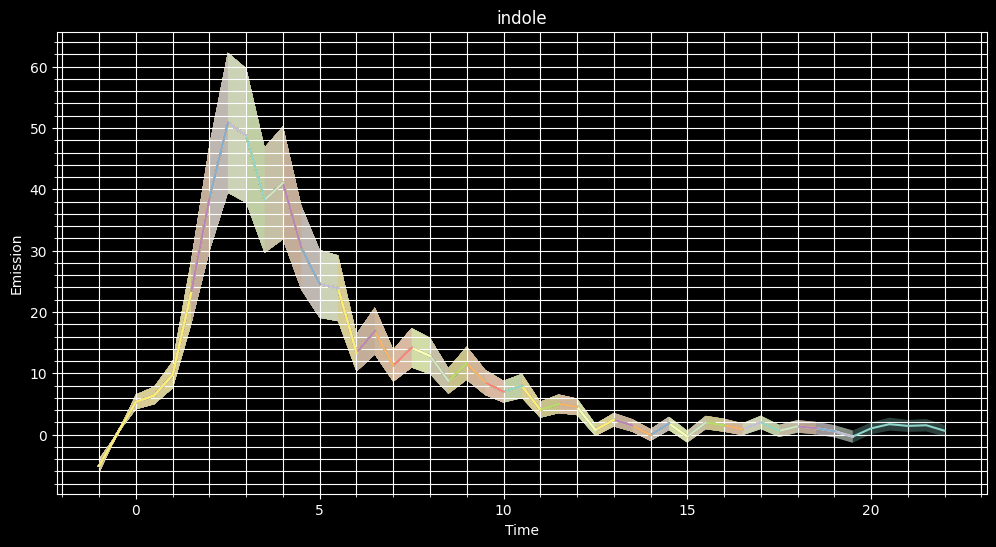

In [89]:
plot_emission_data(os_shortened, plot_type='mean_error', comps = ['indole'], legend = False)

In [90]:
param_config = copy.deepcopy(param_config_indole)

comp = 'indole'
res = []
data = os_shortened
for type in sorted(data.Type.unique()):
    if type not in ['a']:
        print(type)
        try:
            individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
            res.append(individual_results)
        except:
            continue

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='intensity1')
#plot_fit_params_gamma(res, features='intensity1')

save_results_to_csv(res, 'Results_' + comp + '_Single_OS_time_cut_1percent')

w
Channel 54, Type w, R² = 0.804
Channel 62, Type w, R² = 0.939
Channel 67, Type w, R² = 0.847
Channel 86, Type w, R² = 0.953
Channel 95, Type w, R² = 0.963
w10
Channel 102, Type w10, R² = 0.809
Channel 103, Type w10, R² = 0.936
Channel 104, Type w10, R² = 0.843
Channel 105, Type w10, R² = 0.952
Channel 106, Type w10, R² = 0.955
w11
Channel 107, Type w11, R² = 0.809
Channel 108, Type w11, R² = 0.936
Channel 109, Type w11, R² = 0.843
Channel 110, Type w11, R² = 0.952
Channel 111, Type w11, R² = 0.960
w12
Channel 112, Type w12, R² = 0.807
Channel 113, Type w12, R² = 0.935
Channel 114, Type w12, R² = 0.842
Channel 115, Type w12, R² = 0.951
Channel 116, Type w12, R² = 0.960
w13
Channel 117, Type w13, R² = 0.807
Channel 118, Type w13, R² = 0.935
Channel 119, Type w13, R² = 0.842
Channel 120, Type w13, R² = 0.951
Channel 121, Type w13, R² = 0.960
w14
Channel 122, Type w14, R² = 0.805
Channel 123, Type w14, R² = 0.934
Channel 124, Type w14, R² = 0.840
Channel 125, Type w14, R² = 0.951
Channel

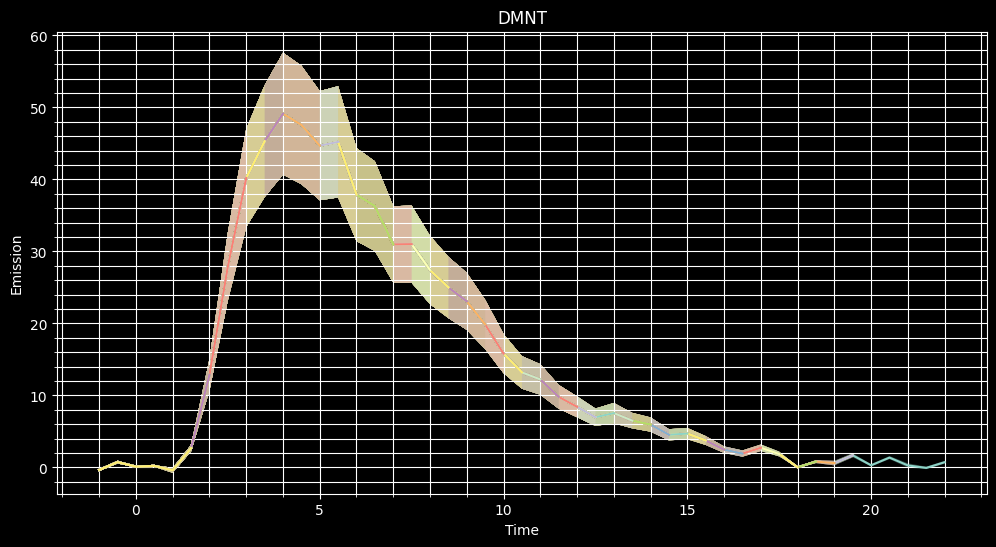

In [91]:
plot_emission_data(os_shortened, plot_type='mean_error', comps = ['DMNT'], legend = False)

In [92]:
param_config = {
    #'R_peak': {'value': 20, 'min': 1, 'max':  600 },
    #'t_peak': {'value': 3.8, 'min': 1, 'max':  15 },
    't_onset': {'value': 1.8, 'min': 0, 'max': 10 },
    't_mean': {'value': 6, 'min': 1, 'max': 20 }
} 

comp = 'DMNT'
res = []
data = os_shortened
for type in sorted(data.Type.unique()):
    if type not in ['a']:
        print(type)
        try:
            individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
            res.append(individual_results)
        except:
            continue

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='intensity1')
#plot_fit_params_gamma(res, features='intensity1')

save_results_to_csv(res, 'Results_' + comp + '_Single_OS_time_cut_1percent')

w
Channel 54, Type w, R² = 0.976
Channel 62, Type w, R² = 0.943
Channel 67, Type w, R² = 0.973
Channel 86, Type w, R² = 0.985
Channel 95, Type w, R² = 0.982
w10
Channel 102, Type w10, R² = 0.973
Channel 103, Type w10, R² = 0.938
Channel 104, Type w10, R² = 0.971
Channel 105, Type w10, R² = 0.984
Channel 106, Type w10, R² = 0.981
w11
Channel 107, Type w11, R² = 0.973
Channel 108, Type w11, R² = 0.938
Channel 109, Type w11, R² = 0.971
Channel 110, Type w11, R² = 0.984
Channel 111, Type w11, R² = 0.981
w12
Channel 112, Type w12, R² = 0.973
Channel 113, Type w12, R² = 0.937
Channel 114, Type w12, R² = 0.970
Channel 115, Type w12, R² = 0.984
Channel 116, Type w12, R² = 0.981
w13
Channel 117, Type w13, R² = 0.973
Channel 118, Type w13, R² = 0.937
Channel 119, Type w13, R² = 0.970
Channel 120, Type w13, R² = 0.984
Channel 121, Type w13, R² = 0.981
w14
Channel 122, Type w14, R² = 0.973
Channel 123, Type w14, R² = 0.937
Channel 124, Type w14, R² = 0.970
Channel 125, Type w14, R² = 0.984
Channel

In [ ]:
plot_emission_data(os_shortened, plot_type='mean_error', comps = ['TMTT'], legend = False)

In [ ]:
param_config = copy.deepcopy(param_config_TMTT)

comp = 'TMTT'
res = []
data = os_shortened
for type in sorted(data.Type.unique()):
    if type not in ['a']:
        print(type)
        try:
            individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
            res.append(individual_results)
        except:
            continue

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='intensity1')
#plot_fit_params_gamma(res, features='intensity1')

save_results_to_csv(res, 'Results_' + comp + '_Single_OS_time_cut_1percent')

# Figure S4: Model Test, resolution

In [93]:
new_dfs = []
next_channel = os_with["Channel_number"].max() + 1

filtered = os_with[os_with["Type"] != "a"]

for perc in range(10, 90, 5):  # 10%, 15%, ... 85% removed
    for ch, df_ch in filtered.groupby("Channel_number"):
        df_ch = df_ch.sort_values("time")
        
        # Calculate how many rows to keep
        keep_frac = (100 - perc) / 100
        step = int(round(1 / keep_frac))  # e.g. 50% keep -> step=2

        # Keep every nth row to simulate lower resolution
        df_down = df_ch.iloc[::step].copy()

        # Assign new channel number
        df_down["Channel_number"] = next_channel
        next_channel += 1

        # Modify intensity and Type
        df_down["intensity1"] = df_down["intensity1"] + perc
        df_down["Type"] = df_down["Type"] + str(perc)

        new_dfs.append(df_down)

# Combine
os_downsampled = pd.concat([filtered] + new_dfs, ignore_index=True)

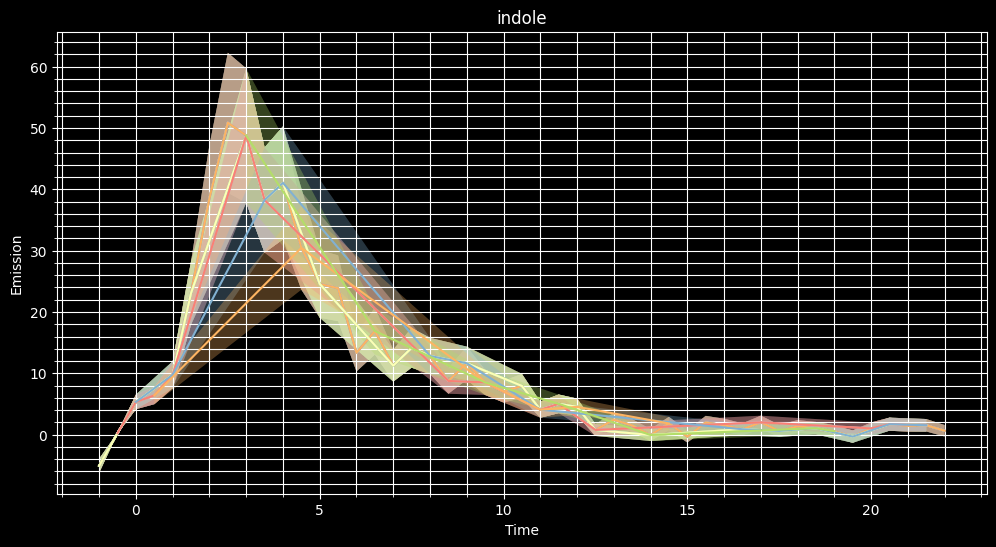

In [94]:
plot_emission_data(os_downsampled, plot_type='mean_error', comps = ['indole'], legend = False)

In [95]:
param_config = copy.deepcopy(param_config_indole)

comp = 'indole'
res = []
data = os_downsampled
for type in sorted(data.Type.unique()):
    if type not in ['a']:
        print(type)
        try:
            individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
            res.append(individual_results)
        except:
            continue

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='intensity1')
#plot_fit_params_gamma(res, features='intensity1')

save_results_to_csv(res, 'Results_' + comp + '_Single_OS_resolution_adjusted')

w
Channel 54, Type w, R² = 0.804
Channel 62, Type w, R² = 0.939
Channel 67, Type w, R² = 0.847
Channel 86, Type w, R² = 0.951
Channel 95, Type w, R² = 0.958
w10
Channel 102, Type w10, R² = 0.804
Channel 103, Type w10, R² = 0.939
Channel 104, Type w10, R² = 0.849
Channel 105, Type w10, R² = 0.953
Channel 106, Type w10, R² = 0.963
w15
Channel 107, Type w15, R² = 0.804
Channel 108, Type w15, R² = 0.939
Channel 109, Type w15, R² = 0.847
Channel 110, Type w15, R² = 0.953
Channel 111, Type w15, R² = 0.963
w20
Channel 112, Type w20, R² = 0.804
Channel 113, Type w20, R² = 0.939
Channel 114, Type w20, R² = 0.847
Channel 115, Type w20, R² = 0.953
Channel 116, Type w20, R² = 0.963
w25
Channel 117, Type w25, R² = 0.804
Channel 118, Type w25, R² = 0.939
Channel 119, Type w25, R² = 0.847
Channel 120, Type w25, R² = 0.953
Channel 121, Type w25, R² = 0.963
w30
Channel 122, Type w30, R² = 0.804
Channel 123, Type w30, R² = 0.939
Channel 124, Type w30, R² = 0.847
Channel 125, Type w30, R² = 0.953
Channel

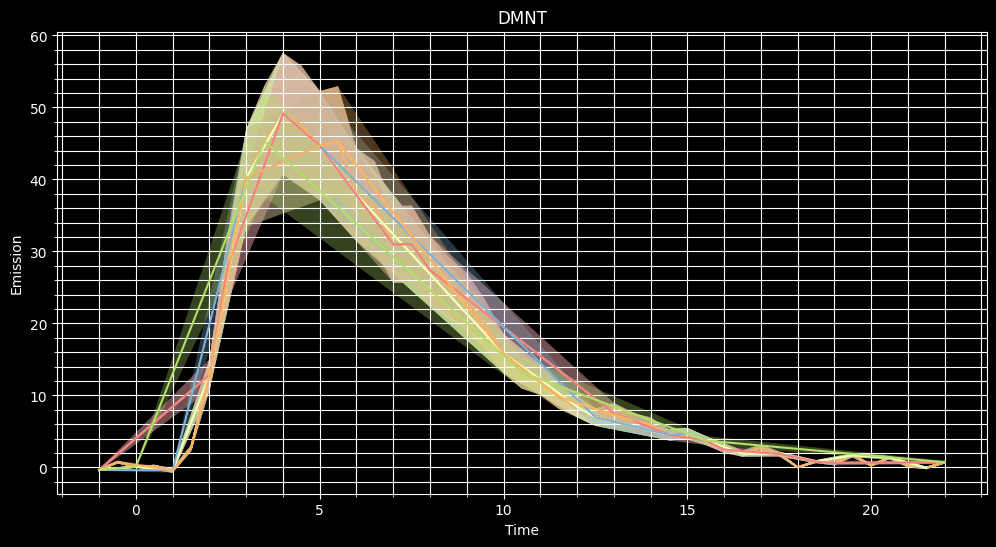

In [96]:
plot_emission_data(os_downsampled, plot_type='mean_error', comps = ['DMNT'], legend = False)

In [97]:
param_config = {
    #'R_peak': {'value': 20, 'min': 1, 'max':  600 },
    #'t_peak': {'value': 3.8, 'min': 1, 'max':  15 },
    't_onset': {'value': 1.8, 'min': 0, 'max': 10 },
    't_mean': {'value': 10, 'min': 1, 'max': 20 }
    #'t_mean': {'value': 6, 'min': 1, 'max': 18 }
} 

comp = 'DMNT'
res = []
data = os_downsampled
for type in sorted(data.Type.unique()):
    if type not in ['r']:
        print(type)
        try:
            individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
            res.append(individual_results)
        except:
            continue

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='intensity1')
#plot_fit_params_gamma(res, features='intensity1')

save_results_to_csv(res, 'Results_' + comp + '_Single_OS_resolution_adjusted')

w
Channel 54, Type w, R² = 0.976
Channel 62, Type w, R² = 0.943
Channel 67, Type w, R² = 0.973
Channel 86, Type w, R² = 0.985
Channel 95, Type w, R² = 0.982
w10
Channel 102, Type w10, R² = 0.976
Channel 103, Type w10, R² = 0.943
Channel 104, Type w10, R² = 0.973
Channel 105, Type w10, R² = 0.985
Channel 106, Type w10, R² = 0.982
w15
Channel 107, Type w15, R² = 0.976
Channel 108, Type w15, R² = 0.943
Channel 109, Type w15, R² = 0.973
Channel 110, Type w15, R² = 0.985
Channel 111, Type w15, R² = 0.982
w20
Channel 112, Type w20, R² = 0.976
Channel 113, Type w20, R² = 0.943
Channel 114, Type w20, R² = 0.973
Channel 115, Type w20, R² = 0.985
Channel 116, Type w20, R² = 0.982
w25
Channel 117, Type w25, R² = 0.976
Channel 118, Type w25, R² = 0.943
Channel 119, Type w25, R² = 0.973
Channel 120, Type w25, R² = 0.985
Channel 121, Type w25, R² = 0.982
w30
Channel 122, Type w30, R² = 0.976
Channel 123, Type w30, R² = 0.943
Channel 124, Type w30, R² = 0.973
Channel 125, Type w30, R² = 0.985
Channel

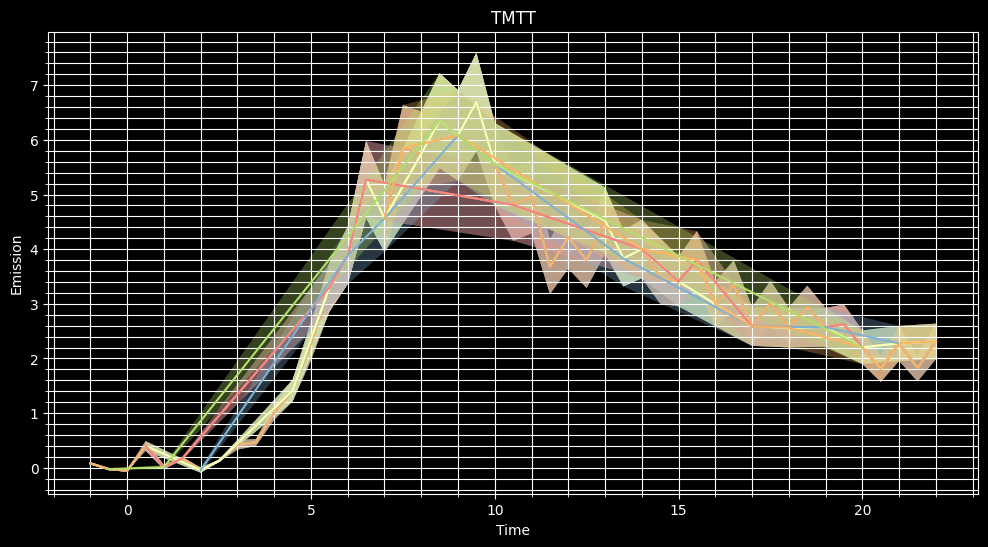

In [98]:
plot_emission_data(os_downsampled, plot_type='mean_error', comps = ['TMTT'], legend = False)

In [99]:
param_config = copy.deepcopy(param_config_TMTT)

comp = 'TMTT'
res = []
data = os_downsampled
for type in sorted(data.Type.unique()):
    if type not in ['a']:
        print(type)
        try:
            individual_results = process_single_group(data, type, comp, param_config, lambda_prior = 1)
            res.append(individual_results)
        except:
            continue

#plot_3d_mean_fitting_results_by_type(res, title = comp)
#plot_fit_results_gamma(res, features='intensity1')
#plot_fit_params_gamma(res, features='intensity1')

save_results_to_csv(res, 'Results_' + comp + '_Single_OS_resolution_adjusted')

w
Channel 54, Type w, R² = 0.888
Channel 62, Type w, R² = 0.763
Channel 67, Type w, R² = 0.797
Channel 86, Type w, R² = 0.800
Channel 95, Type w, R² = 0.905
w10
Channel 102, Type w10, R² = 0.888
Channel 103, Type w10, R² = 0.763
Channel 104, Type w10, R² = 0.797
Channel 105, Type w10, R² = 0.800
Channel 106, Type w10, R² = 0.905
w15
Channel 107, Type w15, R² = 0.888
Channel 108, Type w15, R² = 0.763
Channel 109, Type w15, R² = 0.797
Channel 110, Type w15, R² = 0.795
Channel 111, Type w15, R² = 0.905
w20
Channel 112, Type w20, R² = 0.888
Channel 113, Type w20, R² = 0.763
Channel 114, Type w20, R² = 0.797
Channel 115, Type w20, R² = 0.800
Channel 116, Type w20, R² = 0.905
w25
Channel 117, Type w25, R² = 0.888
Channel 118, Type w25, R² = 0.763
Channel 119, Type w25, R² = 0.797
Channel 120, Type w25, R² = 0.795
Channel 121, Type w25, R² = 0.905
w30
Channel 122, Type w30, R² = 0.888
Channel 123, Type w30, R² = 0.763
Channel 124, Type w30, R² = 0.797
Channel 125, Type w30, R² = 0.800
Channel